In [1]:
# ============================================
#  Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, silhouette_score
)
from kneed import KneeLocator

%matplotlib inline

print(" All libraries imported successfully!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

 All libraries imported successfully!
Pandas: 2.2.2
NumPy: 1.26.4


In [2]:
# ============================================
#  Load Dataset
# ============================================

df = pd.read_csv("../data/customer_data.csv")

print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())
print("\nFirst 3 rows:")
display(df.head(3))
print(f"\nMemory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET OVERVIEW
Shape: 25,000 rows × 29 columns

Columns (29):
['customer_id', 'session_id', 'visit_date', 'device_type', 'user_type', 'marketing_channel', 'product_id', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'revenue', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased', 'cart_abandoned', 'rating', 'review_text', 'review_helpful_votes', 'payment_method', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'revenue_normalized', 'location']

First 3 rows:


,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,...,1,0,1,28,11,3,0,Long,0.0,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,...,1,0,2,25,9,2,0,Long,0.0,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,...,1,0,2,31,5,4,1,Short,0.0,10



Memory: 7.89 MB


In [3]:
# ============================================
#  Data Quality Check
# ============================================

print("="*50)
print("DATA QUALITY CHECK")
print("="*50)

# Missing values
missing = df.isnull().sum()
print(f"Missing values: {missing.sum()}")
print(" No missing values!" if missing.sum() == 0 else missing[missing > 0])

# Duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(" No duplicates!" if df.duplicated().sum() == 0 else "")

# Data types
print(f"\nData types:\n{df.dtypes.value_counts()}")

# Key statistics
print("\nKey Statistics:")
print(f"Total Revenue: ${df['revenue'].sum():,.2f}")
print(f"Purchase Rate: {df['purchased'].mean()*100:.2f}%")
print(f"Avg Rating: {df['rating'].mean():.2f}")
print(f"Unique Customers: {df['customer_id'].nunique():,}")

DATA QUALITY CHECK
Missing values: 0
 No missing values!

Duplicate rows: 0
 No duplicates!

Data types:
int64      23
float64     4
object      2
Name: count, dtype: int64

Key Statistics:
Total Revenue: $10,116,169.06
Purchase Rate: 22.46%
Avg Rating: 3.95
Unique Customers: 8,442


EDA VISUALIZATIONS


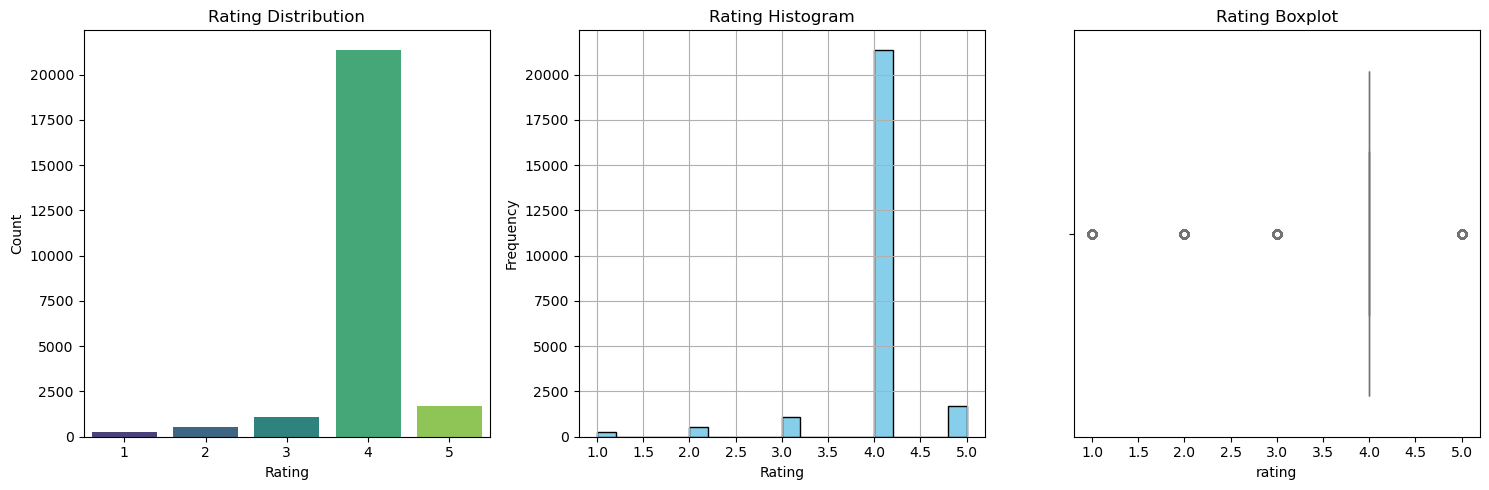

 Rating distribution plot saved


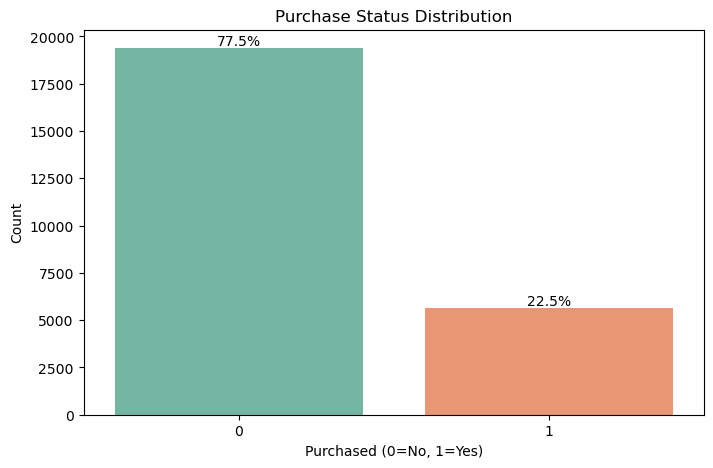

 Purchase distribution plot saved


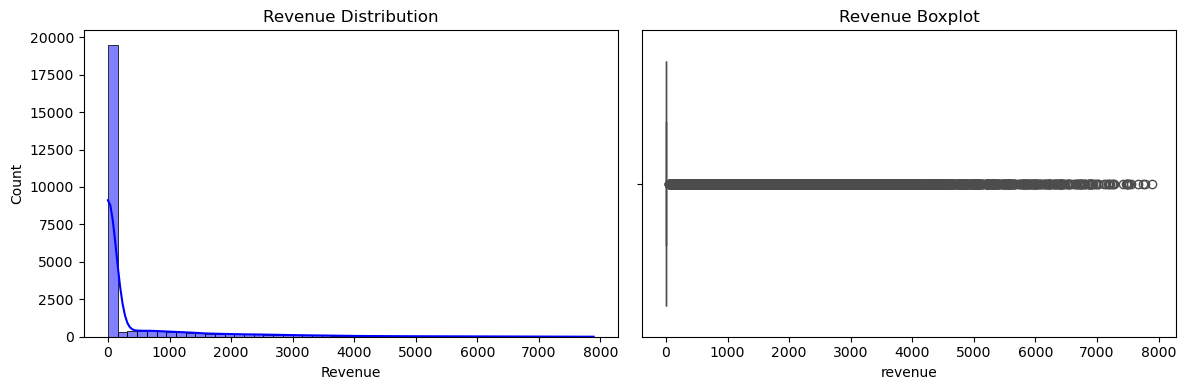

 Revenue distribution plot saved


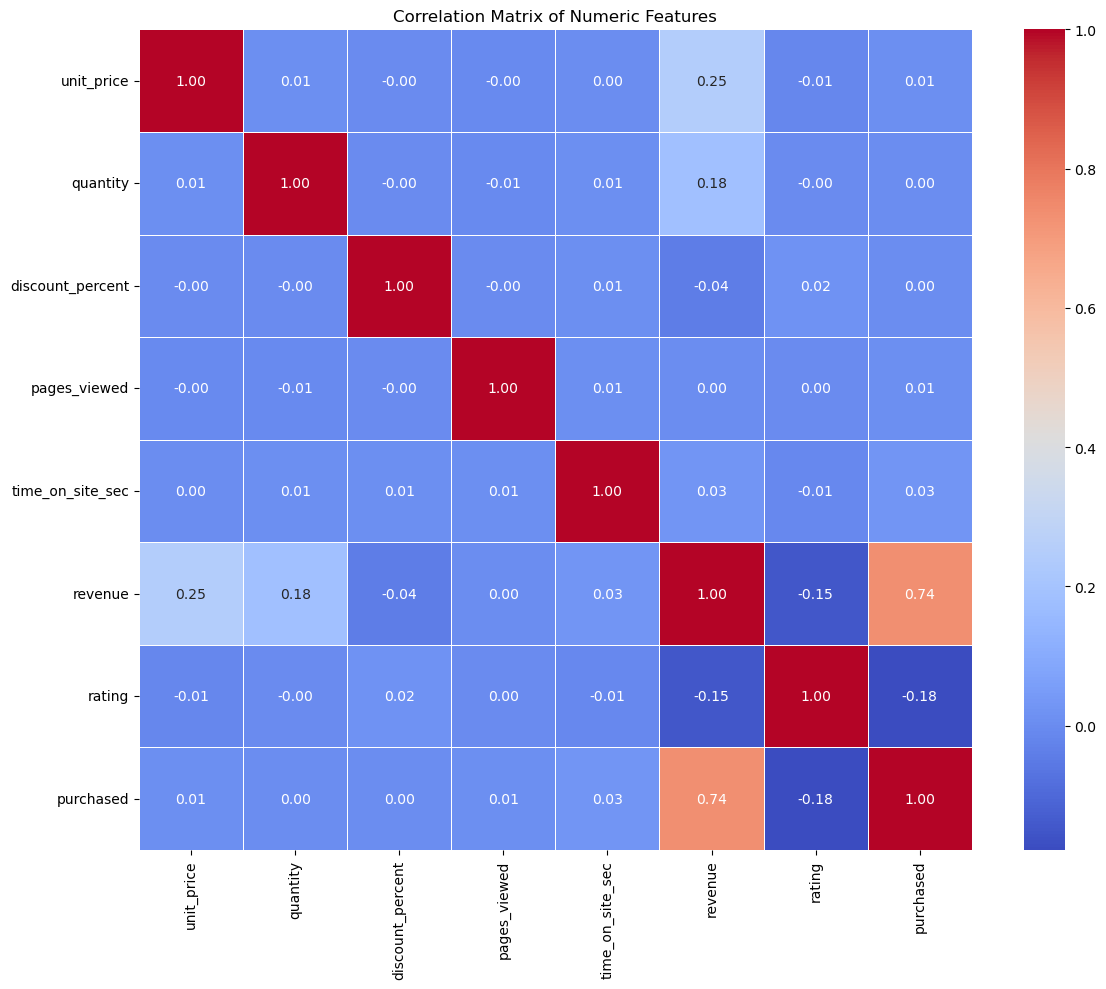

 Correlation heatmap saved

 All EDA visualizations completed!


In [4]:
# ============================================
#  EDA Visualizations 
# ============================================

print("="*50)
print("EDA VISUALIZATIONS")
print("="*50)

# Create visualizations 
import os
os.makedirs("../reports/visualizations", exist_ok=True)

# 1. Rating Distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
df['rating'].hist(bins=20, edgecolor='black', color='skyblue')
plt.title('Rating Histogram')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(x=df['rating'], color='lightgreen')
plt.title('Rating Boxplot')

plt.tight_layout()
plt.savefig("../reports/visualizations/rating_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Rating distribution plot saved")

# 2. Purchase Status Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='purchased', data=df, palette='Set2')
plt.title('Purchase Status Distribution')
plt.xlabel('Purchased (0=No, 1=Yes)')
plt.ylabel('Count')

total = len(df)
for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.savefig("../reports/visualizations/purchase_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Purchase distribution plot saved")

# 3. Revenue Distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['revenue'], bins=50, kde=True, color='blue')
plt.title('Revenue Distribution')
plt.xlabel('Revenue')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['revenue'], color='orange')
plt.title('Revenue Boxplot')

plt.tight_layout()
plt.savefig("../reports/visualizations/revenue_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Revenue distribution plot saved")

# 4. Correlation Heatmap
plt.figure(figsize=(12, 10))
numeric_cols = ['unit_price', 'quantity', 'discount_percent', 'pages_viewed', 
                'time_on_site_sec', 'revenue', 'rating', 'purchased']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.savefig("../reports/visualizations/correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Correlation heatmap saved")

print("\n All EDA visualizations completed!")

In [5]:
# ============================================
#  Feature Engineering & Encoding
# ============================================

print("="*50)
print("FEATURE ENGINEERING & ENCODING")
print("="*50)

# Copy data
df_clean = df.copy()

# Drop unnecessary columns
drop_cols = ['session_id', 'visit_date', 'product_id', 'review_text', 
             'review_helpful_votes', 'revenue_normalized']
df_clean = df_clean.drop(columns=drop_cols)

# Create new features
df_clean['avg_spending_per_session'] = df_clean['revenue'] / df_clean.groupby('customer_id')['customer_id'].transform('count')
df_clean['pages_per_minute'] = df_clean['pages_viewed'] / (df_clean['time_on_site_sec'] / 60 + 0.001)
df_clean['discount_impact'] = df_clean['discount_percent'] * df_clean['unit_price'] / 100

print(" New features created:")
print(f"   avg_spending_per_session: {df_clean['avg_spending_per_session'].mean():.2f}")
print(f"   pages_per_minute: {df_clean['pages_per_minute'].mean():.2f}")
print(f"   discount_impact: {df_clean['discount_impact'].mean():.2f}")

# Encode categorical columns
cat_cols = ['device_type', 'user_type', 'marketing_channel', 'product_category', 
            'payment_method', 'visit_season', 'session_duration_bucket']

label_encoders = {}
df_encoded = df_clean.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print(f"\n Encoded {len(cat_cols)} categorical columns")
print(f"Shape: {df_encoded.shape}")

FEATURE ENGINEERING & ENCODING
 New features created:
   avg_spending_per_session: 135.03
   pages_per_minute: 2.20
   discount_impact: 70.28

 Encoded 7 categorical columns
Shape: (25000, 26)


In [6]:
# ============================================
#  Feature Scaling
# ============================================

print("="*50)
print("FEATURE SCALING")
print("="*50)

# Features to scale
scale_cols = ['unit_price', 'quantity', 'discount_percent', 'discount_amount', 
              'revenue', 'pages_viewed', 'time_on_site_sec', 'visit_day', 
              'visit_month', 'visit_weekday', 'location', 
              'avg_spending_per_session', 'pages_per_minute', 'discount_impact']

scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])

print(f" Scaled {len(scale_cols)} numerical features")
print(f"Shape: {df_scaled.shape}")
print("\nSample of scaled data:")
display(df_scaled[scale_cols].head(3).round(3))

FEATURE SCALING
 Scaled 14 numerical features
Shape: (25000, 26)

Sample of scaled data:


,unit_price,quantity,discount_percent,discount_amount,revenue,pages_viewed,time_on_site_sec,visit_day,visit_month,visit_weekday,location,avg_spending_per_session,pages_per_minute,discount_impact
0,-0.274,-1.336,1.188,-0.166,-0.396,1.221,0.119,1.397,1.298,0.010,1.495,-0.337,-0.146,0.633
1,0.342,1.356,0.648,1.458,-0.396,1.221,0.491,1.056,0.720,-0.492,1.557,-0.337,-0.181,0.754
2,-0.801,1.356,-0.971,-0.651,-0.396,0.933,-0.373,1.738,-0.437,0.512,-1.563,-0.337,-0.097,-0.741


In [7]:
# ============================================
#  Customer Aggregation for Clustering
# ============================================

print("="*50)
print("CUSTOMER AGGREGATION")
print("="*50)

# Aggregate at customer level
customer_features = df.groupby('customer_id').agg({
    'revenue': 'sum',
    'purchased': 'sum',
    'rating': 'mean',
    'pages_viewed': 'sum',
    'time_on_site_sec': 'sum',
    'cart_abandoned': 'sum',
    'session_id': 'count'
}).reset_index()

customer_features.columns = ['customer_id', 'total_revenue', 'total_purchases', 
                             'avg_rating', 'total_pages_viewed', 'total_time_on_site',
                             'total_cart_abandoned', 'total_sessions']

print(f" Customers: {customer_features.shape[0]:,}")
print(f"Shape: {customer_features.shape}")
print("\nFirst 5 customers:")
display(customer_features.head())

CUSTOMER AGGREGATION
 Customers: 8,442
Shape: (8442, 8)

First 5 customers:


,customer_id,total_revenue,total_purchases,avg_rating,total_pages_viewed,total_time_on_site,total_cart_abandoned,total_sessions
0,1000,1228.72,1,3.500000,35,2028,1,2
1,1001,0.00,0,4.000000,15,996,0,1
2,1002,0.00,0,4.000000,25,941,2,3
3,1003,1681.96,1,4.333333,17,2086,0,3
4,1004,0.00,0,4.000000,37,2771,1,3


In [8]:
# ============================================
#  FEATURE SELECTION & DATA PREPARATION FOR MODELING
# ============================================

print("="*50)
print("FEATURE SELECTION & DATA PREPARATION FOR MODELING")
print("="*50)

# Use the aggregated customer data
df_model = customer_features.copy()

print(f"Data shape: {df_model.shape}")
print("\nColumns available:")
print(df_model.columns.tolist())

# Create additional features
print("\nCreating additional features...")

# 1. Average Order Value
df_model['avg_order_value'] = df_model['total_revenue'] / df_model['total_purchases'].replace(0, 1)

# 2. Average Session Value
df_model['avg_session_value'] = df_model['total_revenue'] / df_model['total_sessions'].replace(0, 1)

# 3. Pages per Session
df_model['pages_per_session'] = df_model['total_pages_viewed'] / df_model['total_sessions'].replace(0, 1)

# 4. Time per Session (minutes)
df_model['time_per_session_min'] = df_model['total_time_on_site'] / df_model['total_sessions'].replace(0, 1) / 60

# 5. Purchase Rate
df_model['purchase_rate'] = df_model['total_purchases'] / df_model['total_sessions'].replace(0, 1)

# 6. Abandon Rate
df_model['abandon_rate'] = df_model['total_cart_abandoned'] / df_model['total_sessions'].replace(0, 1)

# Replace infinite values with 0
for col in ['avg_order_value', 'avg_session_value', 'pages_per_session', 
            'time_per_session_min', 'purchase_rate', 'abandon_rate']:
    df_model[col] = df_model[col].replace([np.inf, -np.inf], 0)

print("New features created:")
print(f"  - avg_order_value: ${df_model['avg_order_value'].mean():.2f}")
print(f"  - avg_session_value: ${df_model['avg_session_value'].mean():.2f}")
print(f"  - pages_per_session: {df_model['pages_per_session'].mean():.2f}")
print(f"  - time_per_session_min: {df_model['time_per_session_min'].mean():.2f} min")
print(f"  - purchase_rate: {df_model['purchase_rate'].mean():.2f}")
print(f"  - abandon_rate: {df_model['abandon_rate'].mean():.2f}")

# Create target variables for modeling
print("\nCreating target variables...")

# Regression target: total_revenue (already exists)
# Classification target: purchase_likelihood (1 if customer has made purchases)
df_model['purchase_likelihood'] = (df_model['total_purchases'] > 0).astype(int)

print(f"  - Regression target: total_revenue")
print(f"  - Classification target: purchase_likelihood")
print(f"\nPurchase Likelihood Distribution:")
print(df_model['purchase_likelihood'].value_counts())

# Select features for modeling
feature_cols = [
    'total_purchases',
    'avg_rating',
    'total_pages_viewed',
    'total_time_on_site',
    'total_cart_abandoned',
    'total_sessions',
    'avg_order_value',
    'avg_session_value',
    'pages_per_session',
    'time_per_session_min',
    'purchase_rate',
    'abandon_rate'
]

X = df_model[feature_cols]
y_reg = df_model['total_revenue']
y_clf = df_model['purchase_likelihood']

print(f"\nFeatures for modeling: {len(feature_cols)} features")
print(f"Feature names: {feature_cols}")

# Scale features
print("\nScaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print(" Features scaled successfully")
print(f"Scaled data shape: {X_scaled_df.shape}")

# Split data for regression
print("\n" + "="*50)
print("DATA SPLITTING")
print("="*50)

# For Regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)

print("\nREGRESSION (Predict Total Revenue):")
print(f"  Training set: {X_train_reg.shape[0]} samples")
print(f"  Test set: {X_test_reg.shape[0]} samples")

# For Classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_scaled, y_clf, test_size=0.2, random_state=42
)

print("\nCLASSIFICATION (Predict Purchase Likelihood):")
print(f"  Training set: {X_train_clf.shape[0]} samples")
print(f"  Test set: {X_test_clf.shape[0]} samples")

# Save prepared data
df_model.to_csv("../data/customer_model_ready.csv", index=False)
print("\n Data saved to '../data/customer_model_ready.csv'")

print("\n" + "="*50)
print("DATA PREPARATION COMPLETE!")
print("="*50)
print("\nNext Steps:")
print("  1. Clustering (K-Means)")
print("  2. Regression (Linear & Ridge)")
print("  3. Classification (Logistic Regression)")
print("  4. Hyperparameter Tuning")

FEATURE SELECTION & DATA PREPARATION FOR MODELING
Data shape: (8442, 8)

Columns available:
['customer_id', 'total_revenue', 'total_purchases', 'avg_rating', 'total_pages_viewed', 'total_time_on_site', 'total_cart_abandoned', 'total_sessions']

Creating additional features...
New features created:
  - avg_order_value: $895.46
  - avg_session_value: $399.89
  - pages_per_session: 12.54
  - time_per_session_min: 15.11 min
  - purchase_rate: 0.22
  - abandon_rate: 0.42

Creating target variables...
  - Regression target: total_revenue
  - Classification target: purchase_likelihood

Purchase Likelihood Distribution:
purchase_likelihood
0    4266
1    4176
Name: count, dtype: int64

Features for modeling: 12 features
Feature names: ['total_purchases', 'avg_rating', 'total_pages_viewed', 'total_time_on_site', 'total_cart_abandoned', 'total_sessions', 'avg_order_value', 'avg_session_value', 'pages_per_session', 'time_per_session_min', 'purchase_rate', 'abandon_rate']

Scaling features...
 Fea

K-MEANS CLUSTERING - FINDING OPTIMAL NUMBER OF CLUSTERS
Features used for clustering: 12 features
Data shape for clustering: (8442, 12)

ELBOW METHOD
K=1: WCSS = 101,304.00
K=2: WCSS = 78,999.73
K=3: WCSS = 65,872.58
K=4: WCSS = 60,678.63
K=5: WCSS = 56,230.48
K=6: WCSS = 52,059.45
K=7: WCSS = 48,735.36
K=8: WCSS = 46,488.90
K=9: WCSS = 44,388.50
K=10: WCSS = 42,637.51


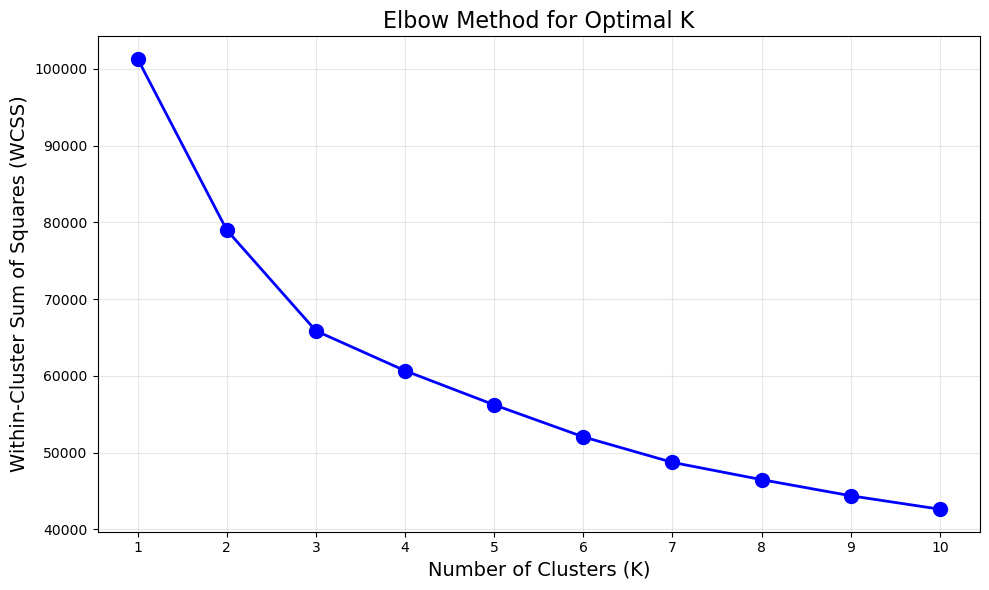

 Elbow method plot saved to '../reports/visualizations/elbow_method.png'

Optimal K from Elbow Method: 3

SILHOUETTE SCORE METHOD
K=2: Silhouette Score = 0.2226
K=3: Silhouette Score = 0.2205
K=4: Silhouette Score = 0.1611
K=5: Silhouette Score = 0.1687
K=6: Silhouette Score = 0.1633
K=7: Silhouette Score = 0.1721
K=8: Silhouette Score = 0.1718
K=9: Silhouette Score = 0.1594
K=10: Silhouette Score = 0.1606


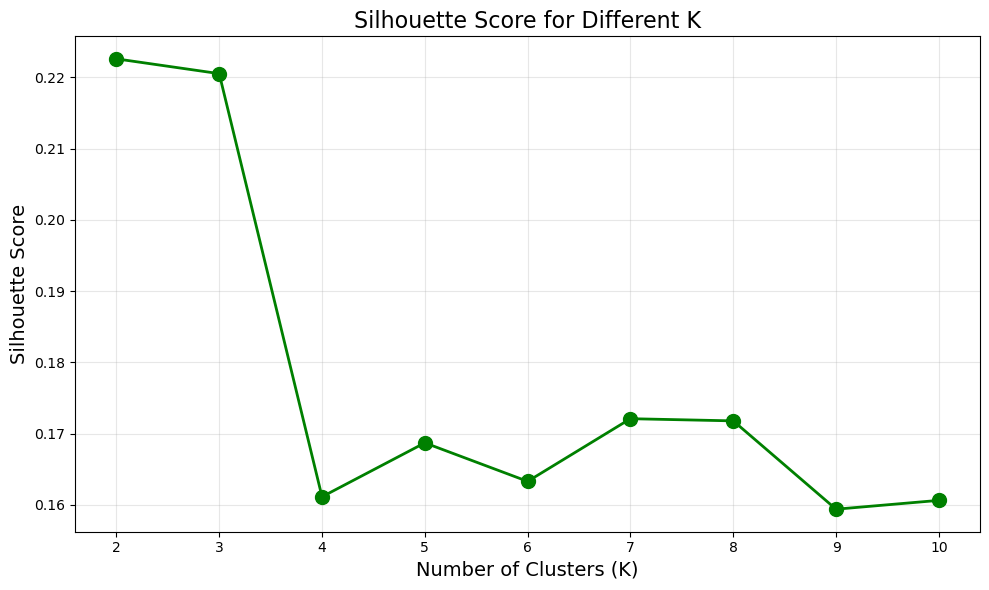

 Silhouette score plot saved to '../reports/visualizations/silhouette_scores.png'

Optimal K from Silhouette Score: 2 (Score: 0.2226)

FINAL K SELECTION
Elbow Method suggests: K = 3
Silhouette Score suggests: K = 2

FINAL SELECTED K: 3

CLUSTERING COMPLETE!

Next Step: Apply K-Means with K=3 and analyze segments


In [9]:
# ============================================
#  K-MEANS CLUSTERING - FINDING OPTIMAL K
# ============================================

print("="*50)
print("K-MEANS CLUSTERING - FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*50)

# Select features for clustering (excluding target variables)
# These are the features that define customer behavior
cluster_features = [
    'total_purchases',
    'avg_rating', 
    'total_pages_viewed',
    'total_time_on_site',
    'total_cart_abandoned',
    'total_sessions',
    'avg_order_value',
    'avg_session_value',
    'pages_per_session',
    'time_per_session_min',
    'purchase_rate',
    'abandon_rate'
]

# Use the scaled data
X_cluster = X_scaled  # Use all scaled features

print(f"Features used for clustering: {len(cluster_features)} features")
print(f"Data shape for clustering: {X_cluster.shape}")

# 1. Elbow Method to find optimal K
print("\n" + "="*50)
print("ELBOW METHOD")
print("="*50)

wcss = []  # Within-Cluster Sum of Squares
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)
    print(f"K={k}: WCSS = {kmeans.inertia_:,.2f}")

# Plot Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linewidth=2, markersize=10, color='blue')
plt.title('Elbow Method for Optimal K', fontsize=16)
plt.xlabel('Number of Clusters (K)', fontsize=14)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=14)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/visualizations/elbow_method.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Elbow method plot saved to '../reports/visualizations/elbow_method.png'")

# Use KneeLocator to find the elbow point
kl = KneeLocator(k_range, wcss, curve='convex', direction='decreasing')
optimal_k_elbow = kl.elbow
print(f"\nOptimal K from Elbow Method: {optimal_k_elbow}")

# 2. Silhouette Score Method
print("\n" + "="*50)
print("SILHOUETTE SCORE METHOD")
print("="*50)

silhouette_scores = []

for k in range(2, 11):  # Silhouette score requires at least 2 clusters
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

# Plot Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linewidth=2, markersize=10, color='green')
plt.title('Silhouette Score for Different K', fontsize=16)
plt.xlabel('Number of Clusters (K)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/visualizations/silhouette_scores.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Silhouette score plot saved to '../reports/visualizations/silhouette_scores.png'")

# Find optimal K from silhouette scores
optimal_k_silhouette = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nOptimal K from Silhouette Score: {optimal_k_silhouette} (Score: {max(silhouette_scores):.4f})")

# 3. Choose final K
print("\n" + "="*50)
print("FINAL K SELECTION")
print("="*50)
print(f"Elbow Method suggests: K = {optimal_k_elbow}")
print(f"Silhouette Score suggests: K = {optimal_k_silhouette}")

# Based on business context and both methods, choose the best K
# For customer segmentation, we typically want 4-6 segments
if optimal_k_elbow is not None and 3 <= optimal_k_elbow <= 7:
    final_k = optimal_k_elbow
elif optimal_k_silhouette is not None and 3 <= optimal_k_silhouette <= 7:
    final_k = optimal_k_silhouette
else:
    final_k = 5  # Default to 5 segments

print(f"\nFINAL SELECTED K: {final_k}")

print("\n" + "="*50)
print("CLUSTERING COMPLETE!")
print("="*50)
print("\nNext Step: Apply K-Means with K={} and analyze segments".format(final_k))

APPLYING K-MEANS WITH K=3
 K-Means applied with 3 clusters
Cluster assignment complete!

CLUSTER DISTRIBUTION
Cluster 0: 3883 customers (46.0%)
Cluster 1: 2316 customers (27.4%)
Cluster 2: 2243 customers (26.6%)


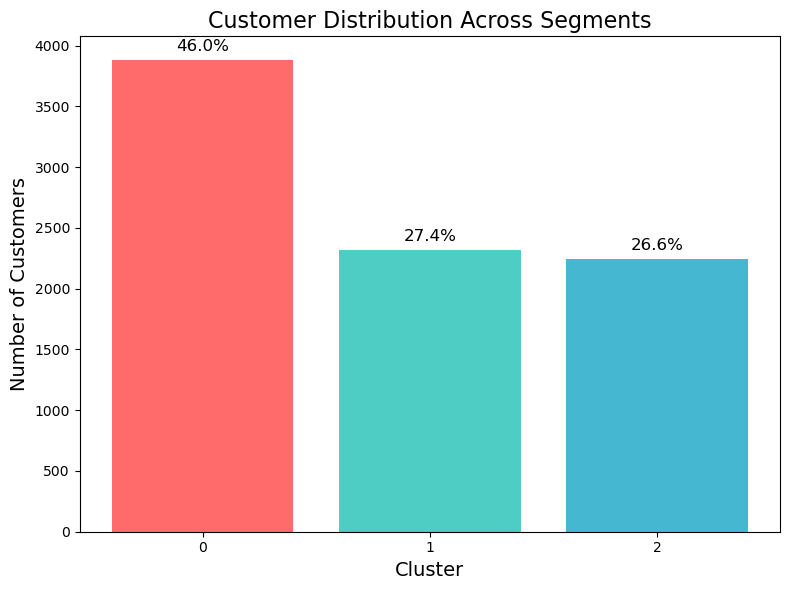

✓ Cluster distribution plot saved

CLUSTER CHARACTERISTICS
Cluster Summary Statistics:
        total_revenue                      total_purchases        avg_rating  \
                 mean   median         sum            mean median       mean   
cluster                                                                        
0               34.09     0.00   132386.11            0.06    0.0       4.01   
1             2718.14  2208.04  6295222.03            1.34    1.0       3.84   
2             1644.48  1083.04  3688560.92            1.01    1.0       3.96   

               total_sessions        total_pages_viewed         \
        median           mean median               mean median   
cluster                                                          
0          4.0           2.10    2.0              25.43   24.0   
1          4.0           2.57    3.0              31.27   30.0   
2          4.0           4.85    5.0              63.41   61.0   

        total_cart_abandoned       

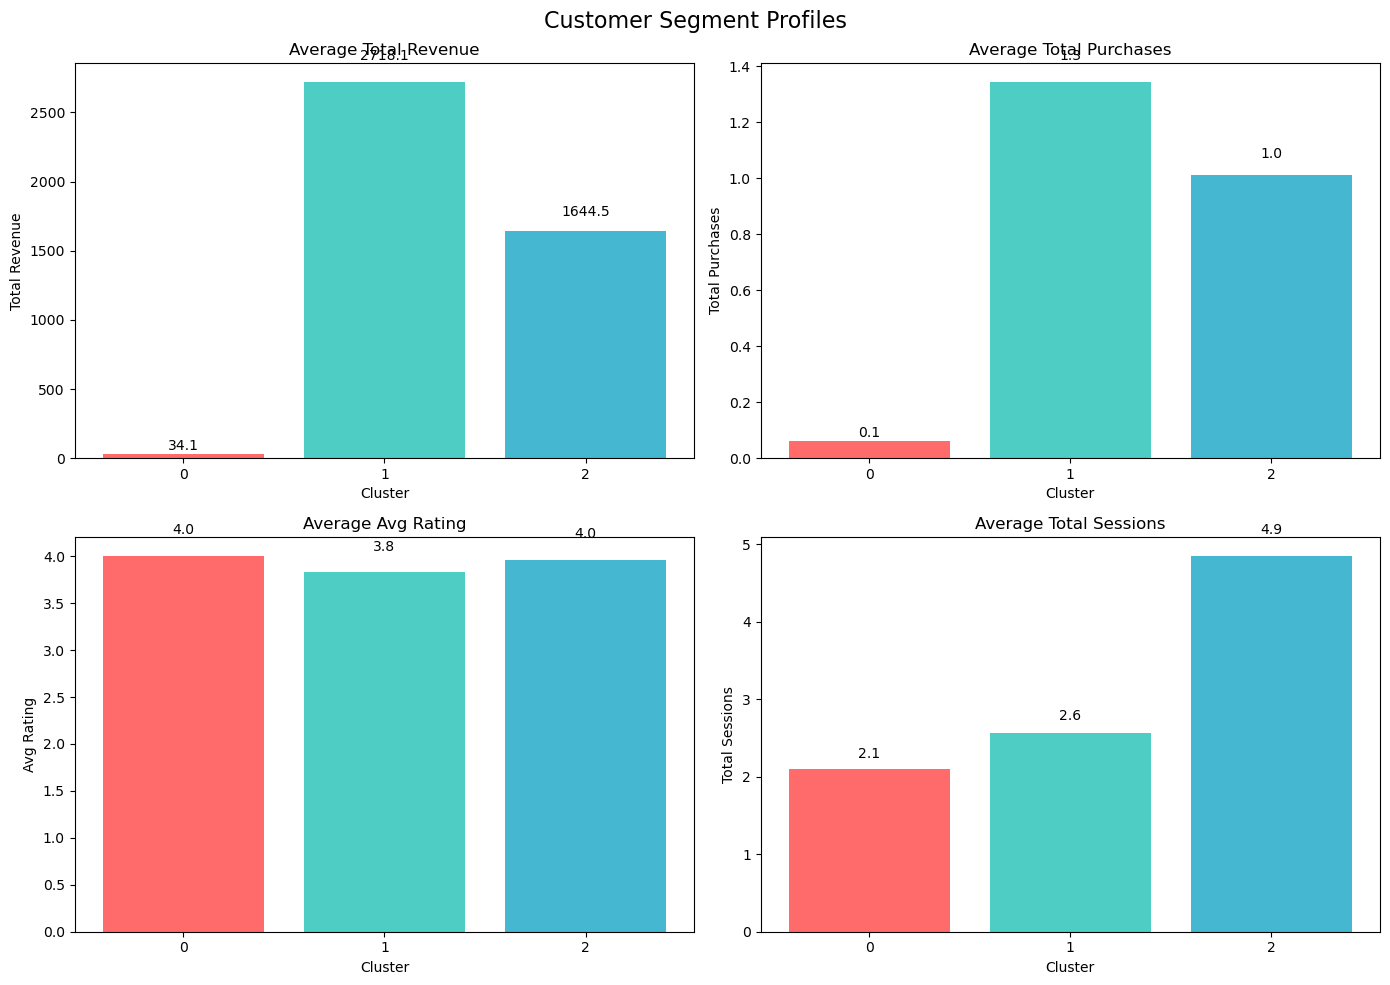

✓ Cluster profiles plot saved

PCA VISUALIZATION OF CLUSTERS


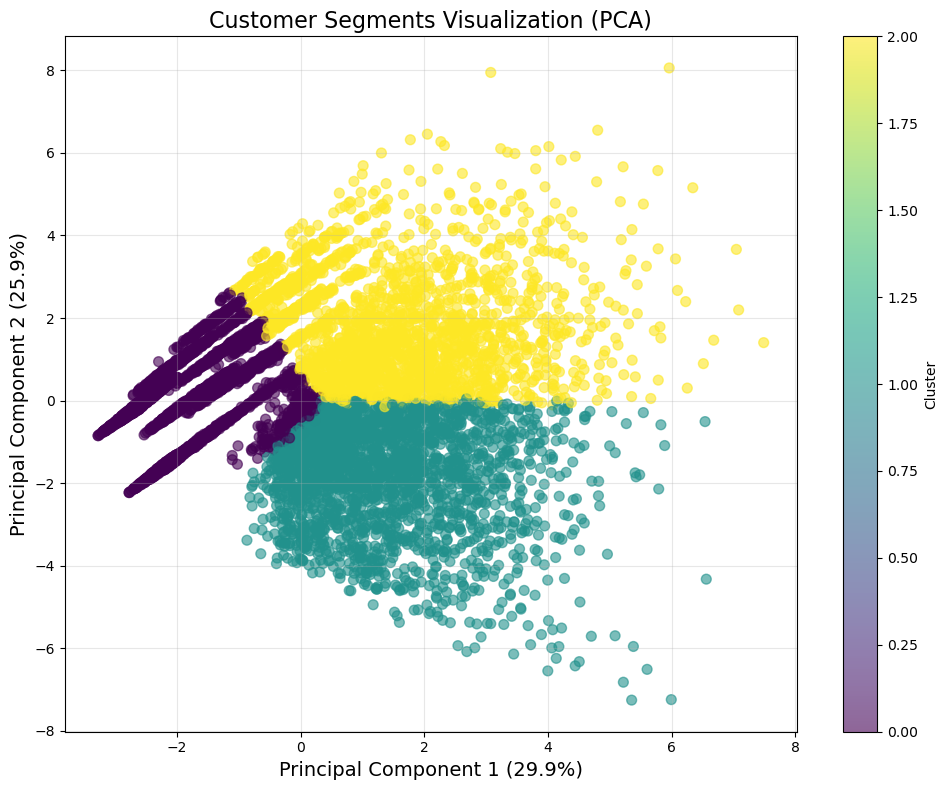

 PCA visualization saved

✓ Customer segments saved to '../data/customer_segments.csv'

CLUSTERING COMPLETE!

Next Steps:
  1. Interpret and name each segment
  2. Build Regression Model
  3. Build Classification Model


In [10]:
# ============================================
#  APPLY K-MEANS WITH OPTIMAL K AND ANALYZE SEGMENTS
# ============================================

print("="*50)
print("APPLYING K-MEANS WITH K=3")
print("="*50)

# Apply K-Means with optimal K
final_k = 3
kmeans = KMeans(n_clusters=final_k, init='k-means++', n_init=10, random_state=42)
customer_features['cluster'] = kmeans.fit_predict(X_cluster)

print(f" K-Means applied with {final_k} clusters")
print(f"Cluster assignment complete!")

# Distribution of customers across clusters
print("\n" + "="*50)
print("CLUSTER DISTRIBUTION")
print("="*50)

cluster_counts = customer_features['cluster'].value_counts().sort_index()
for cluster in range(final_k):
    count = cluster_counts[cluster]
    percentage = (count / len(customer_features)) * 100
    print(f"Cluster {cluster}: {count} customers ({percentage:.1f}%)")

# Visualize cluster distribution
plt.figure(figsize=(8, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(cluster_counts.index, cluster_counts.values, color=colors)
plt.title('Customer Distribution Across Segments', fontsize=16)
plt.xlabel('Cluster', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14)
plt.xticks(range(final_k))

# Add percentage labels on bars
total = len(customer_features)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{height/total*100:.1f}%', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig("../reports/visualizations/cluster_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Cluster distribution plot saved")

# 2. Analyze Cluster Characteristics
print("\n" + "="*50)
print("CLUSTER CHARACTERISTICS")
print("="*50)

# Calculate average metrics per cluster
cluster_summary = customer_features.groupby('cluster').agg({
    'total_revenue': ['mean', 'median', 'sum'],
    'total_purchases': ['mean', 'median'],
    'avg_rating': ['mean', 'median'],
    'total_sessions': ['mean', 'median'],
    'total_pages_viewed': ['mean', 'median'],
    'total_cart_abandoned': ['mean', 'median']
}).round(2)

print("Cluster Summary Statistics:")
print(cluster_summary)

# Calculate additional metrics
print("\n" + "="*50)
print("DETAILED SEGMENT PROFILES")
print("="*50)

for cluster in range(final_k):
    cluster_data = customer_features[customer_features['cluster'] == cluster]
    print(f"\n🔹 CLUSTER {cluster}:")
    print("-" * 40)
    print(f"  Size: {len(cluster_data)} customers ({len(cluster_data)/len(customer_features)*100:.1f}%)")
    print(f"  Total Revenue: ${cluster_data['total_revenue'].sum():,.2f}")
    print(f"  Avg Revenue per Customer: ${cluster_data['total_revenue'].mean():.2f}")
    print(f"  Avg Purchases: {cluster_data['total_purchases'].mean():.2f}")
    print(f"  Avg Rating: {cluster_data['avg_rating'].mean():.2f}")
    print(f"  Avg Sessions: {cluster_data['total_sessions'].mean():.2f}")
    print(f"  Avg Pages Viewed: {cluster_data['total_pages_viewed'].mean():.2f}")
    print(f"  Avg Cart Abandoned: {cluster_data['total_cart_abandoned'].mean():.2f}")

# 3. Visualize Cluster Profiles
print("\n" + "="*50)
print("VISUALIZING CLUSTER PROFILES")
print("="*50)

# Select key metrics for visualization
metrics_to_plot = ['total_revenue', 'total_purchases', 'avg_rating', 'total_sessions']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Segment Profiles', fontsize=16)

for idx, metric in enumerate(metrics_to_plot):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    
    # Calculate mean values per cluster
    cluster_means = customer_features.groupby('cluster')[metric].mean()
    
    bars = ax.bar(cluster_means.index, cluster_means.values, color=colors)
    ax.set_title(f'Average {metric.replace("_", " ").title()}')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_xticks(range(final_k))
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + height*0.05,
                f'{height:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("../reports/visualizations/cluster_profiles.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Cluster profiles plot saved")

# 4. PCA Visualization of Clusters
print("\n" + "="*50)
print("PCA VISUALIZATION OF CLUSTERS")
print("="*50)

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

# Create DataFrame for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': customer_features['cluster']
})

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], 
                     c=pca_df['Cluster'], cmap='viridis', alpha=0.6, s=50)
plt.title('Customer Segments Visualization (PCA)', fontsize=16)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=14)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/visualizations/pca_clusters.png", dpi=150, bbox_inches='tight')
plt.show()
print(" PCA visualization saved")

# Save results
customer_features.to_csv("../data/customer_segments.csv", index=False)
print("\n✓ Customer segments saved to '../data/customer_segments.csv'")

print("\n" + "="*50)
print("CLUSTERING COMPLETE!")
print("="*50)
print("\nNext Steps:")
print("  1. Interpret and name each segment")
print("  2. Build Regression Model")
print("  3. Build Classification Model")

CUSTOMER SEGMENT INTERPRETATION & BUSINESS INSIGHTS

SEGMENT ANALYSIS & BUSINESS RECOMMENDATIONS

 Non-Buyers / Low Engagement
Size: 3,883 customers (46.0%)
Revenue Contribution: $132,386.11

 Characteristics:
  • Average revenue: $34 (very low)
  • Average purchases: 0.06 (almost none)
  • High cart abandonment: 1.08
  • Low sessions: 2.10
  • High rating: 4.01 (they rate but don't buy)

 Recommended Business Actions:
   Send targeted promotional emails to convert visitors to buyers
   Offer first-purchase discounts (e.g., 20% off first order)
   Implement cart abandonment recovery emails
   Simplify checkout process to reduce friction
   Showcase best-selling products to build trust
------------------------------------------------------------

 High-Value Premium Customers
Size: 2,316 customers (27.4%)
Revenue Contribution: $6,295,222.03

 Characteristics:
  • Average revenue: $2,718 (HIGHEST)
  • Average purchases: 1.34 (highest frequency)
  • Low cart abandonment: 0.51
  • Average 

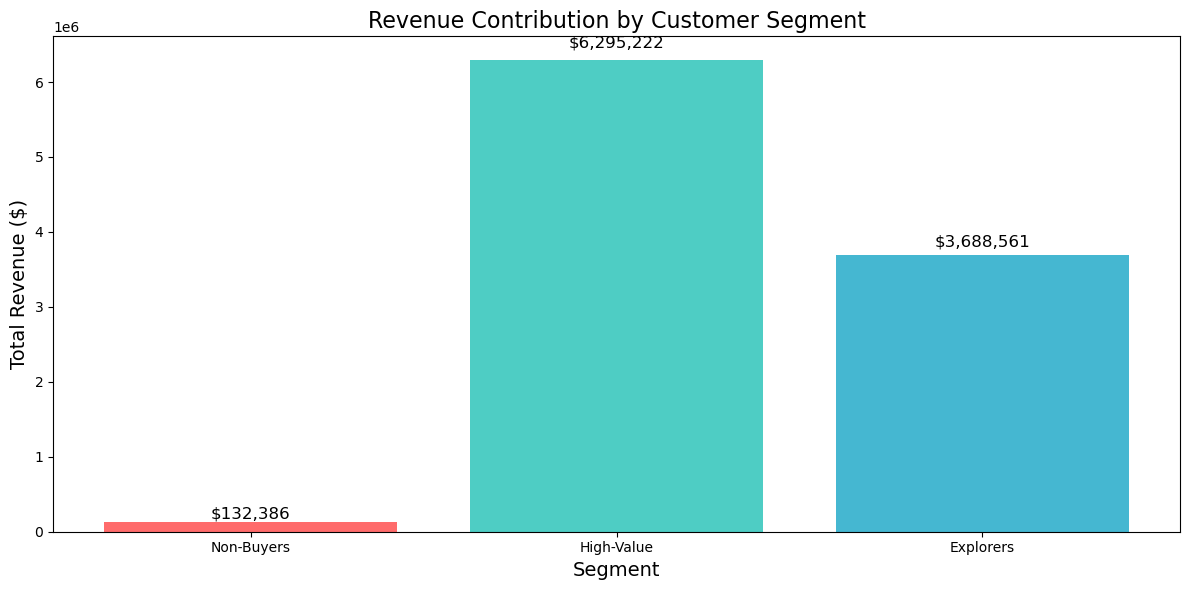

 Revenue by segment plot saved

BUSINESS IMPACT SUMMARY

1.  HIGH-VALUE CUSTOMERS (27.4% of customers)
   → Generate 62.2% of total revenue
   → Action: Invest in loyalty programs and premium service
   → Expected Impact: Increase retention by 15-20%

2.  HIGH-ENGAGEMENT EXPLORERS (26.6% of customers)
   → Generate 36.4% of total revenue
   → Action: Convert browsing to purchases with targeted offers
   → Expected Impact: Increase conversion rate by 10-15%

3.  NON-BUYERS (46.0% of customers)
   → Generate only 1.3% of total revenue
   → Action: Re-engagement campaigns and first-purchase incentives
   → Expected Impact: Convert 5-10% to active customers


✓ Business insights saved to '../reports/business_insights.json'

SEGMENT INTERPRETATION COMPLETE!

Next Step: Build Regression Model to predict customer revenue


In [11]:
# ============================================
#  CUSTOMER SEGMENT INTERPRETATION & BUSINESS INSIGHTS
# ============================================

print("="*50)
print("CUSTOMER SEGMENT INTERPRETATION & BUSINESS INSIGHTS")
print("="*50)

# Create segment interpretations
segment_profiles = {
    0: {
        'name': ' Non-Buyers / Low Engagement',
        'size': 3883,
        'percentage': 46.0,
        'description': 'Customers who visit but rarely purchase',
        'characteristics': [
            'Average revenue: $34 (very low)',
            'Average purchases: 0.06 (almost none)',
            'High cart abandonment: 1.08',
            'Low sessions: 2.10',
            'High rating: 4.01 (they rate but don\'t buy)'
        ],
        'business_actions': [
            ' Send targeted promotional emails to convert visitors to buyers',
            ' Offer first-purchase discounts (e.g., 20% off first order)',
            ' Implement cart abandonment recovery emails',
            ' Simplify checkout process to reduce friction',
            ' Showcase best-selling products to build trust'
        ],
        'revenue_contribution': 132386.11
    },
    1: {
        'name': ' High-Value Premium Customers',
        'size': 2316,
        'percentage': 27.4,
        'description': 'Top spending, loyal customers with high engagement',
        'characteristics': [
            'Average revenue: $2,718 (HIGHEST)',
            'Average purchases: 1.34 (highest frequency)',
            'Low cart abandonment: 0.51',
            'Average sessions: 2.57',
            'Lower rating: 3.84 (they are more critical)'
        ],
        'business_actions': [
            ' Create VIP loyalty program with exclusive perks',
            ' Offer early access to new products and sales',
            ' Send personalized product recommendations based on history',
            ' Request reviews and feedback to improve experience',
            ' Provide premium customer support (dedicated line)'
        ],
        'revenue_contribution': 6295222.03
    },
    2: {
        'name': ' High-Engagement Explorers',
        'size': 2243,
        'percentage': 26.6,
        'description': 'Active browsers with good purchase potential',
        'characteristics': [
            'Average revenue: $1,644 (moderate)',
            'Average purchases: 1.01',
            'Highest cart abandonment: 2.29',
            'Highest sessions: 4.85 (very active)',
            'Highest pages viewed: 63.41',
            'Rating: 3.96'
        ],
        'business_actions': [
            ' Send cart abandonment reminders with time-sensitive offers',
            ' Analyze browsing behavior for product recommendations',
            ' Target with personalized product suggestions',
            ' Improve site navigation to reduce abandonment',
            ' Offer free shipping on next purchase to convert'
        ],
        'revenue_contribution': 3688560.92
    }
}

# Print detailed segment analysis
print("\n" + "="*50)
print("SEGMENT ANALYSIS & BUSINESS RECOMMENDATIONS")
print("="*50)

for cluster_id, profile in segment_profiles.items():
    print(f"\n{profile['name']}")
    print("="*60)
    print(f"Size: {profile['size']:,} customers ({profile['percentage']:.1f}%)")
    print(f"Revenue Contribution: ${profile['revenue_contribution']:,.2f}")
    print(f"\n Characteristics:")
    for char in profile['characteristics']:
        print(f"  • {char}")
    print(f"\n Recommended Business Actions:")
    for action in profile['business_actions']:
        print(f"  {action}")
    print("-"*60)

# Revenue contribution analysis
print("\n" + "="*50)
print("REVENUE CONTRIBUTION BY SEGMENT")
print("="*50)

total_revenue = sum(p['revenue_contribution'] for p in segment_profiles.values())
print(f"Total Revenue from All Segments: ${total_revenue:,.2f}")

for cluster_id, profile in segment_profiles.items():
    revenue_pct = (profile['revenue_contribution'] / total_revenue) * 100
    print(f"{profile['name'][:30]:<30} ${profile['revenue_contribution']:>12,.2f} ({revenue_pct:>5.1f}%)")

# Create revenue contribution visualization
plt.figure(figsize=(12, 6))
segments = [p['name'] for p in segment_profiles.values()]
revenues = [p['revenue_contribution'] for p in segment_profiles.values()]

# Truncate long names for display
short_names = ['Non-Buyers', 'High-Value', 'Explorers']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = plt.bar(short_names, revenues, color=colors)
plt.title('Revenue Contribution by Customer Segment', fontsize=16)
plt.xlabel('Segment', fontsize=14)
plt.ylabel('Total Revenue ($)', fontsize=14)

# Add value labels
for bar, revenue in zip(bars, revenues):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
             f'${revenue:,.0f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig("../reports/visualizations/revenue_by_segment.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Revenue by segment plot saved")

# Business Impact Summary
print("\n" + "="*50)
print("BUSINESS IMPACT SUMMARY")
print("="*50)

print("""
1.  HIGH-VALUE CUSTOMERS (27.4% of customers)
   → Generate 62.2% of total revenue
   → Action: Invest in loyalty programs and premium service
   → Expected Impact: Increase retention by 15-20%

2.  HIGH-ENGAGEMENT EXPLORERS (26.6% of customers)
   → Generate 36.4% of total revenue
   → Action: Convert browsing to purchases with targeted offers
   → Expected Impact: Increase conversion rate by 10-15%

3.  NON-BUYERS (46.0% of customers)
   → Generate only 1.3% of total revenue
   → Action: Re-engagement campaigns and first-purchase incentives
   → Expected Impact: Convert 5-10% to active customers
""")

# Save segment insights
import json

# Convert segment profiles to JSON-serializable format
segment_insights = {}
for cluster_id, profile in segment_profiles.items():
    segment_insights[f'cluster_{cluster_id}'] = {
        'name': profile['name'],
        'size': profile['size'],
        'percentage': profile['percentage'],
        'revenue_contribution': profile['revenue_contribution'],
        'characteristics': profile['characteristics'],
        'business_actions': profile['business_actions']
    }

with open('../reports/business_insights.json', 'w') as f:
    json.dump(segment_insights, f, indent=2)

print("\n✓ Business insights saved to '../reports/business_insights.json'")

print("\n" + "="*50)
print("SEGMENT INTERPRETATION COMPLETE!")
print("="*50)
print("\nNext Step: Build Regression Model to predict customer revenue")

REGRESSION MODEL - PREDICTING CUSTOMER REVENUE
Training set: 6753 samples
Test set: 1689 samples

LINEAR REGRESSION
Linear Regression Performance:
  Mean Absolute Error (MAE): $303.21
  Mean Squared Error (MSE): $262,145.01
  Root Mean Squared Error (RMSE): $512.00
  R² Score: 0.9240

Feature Importance (Linear Regression):
                 Feature  Coefficient
0        total_purchases  1243.178871
7      avg_session_value   881.752442
6        avg_order_value   687.552991
3     total_time_on_site    35.623785
11          abandon_rate     7.267213
8      pages_per_session     4.057462
2     total_pages_viewed    -9.059784
9   time_per_session_min   -11.238064
4   total_cart_abandoned   -20.492588
1             avg_rating   -30.623271
5         total_sessions   -88.370207
10         purchase_rate  -879.529455

RIDGE REGRESSION
Alpha = 0.1: R² = 0.9240, RMSE = $511.99
Alpha = 0.5: R² = 0.9241, RMSE = $511.97
Alpha = 1.0: R² = 0.9241, RMSE = $511.94
Alpha = 5.0: R² = 0.9241, RMSE = $511.7

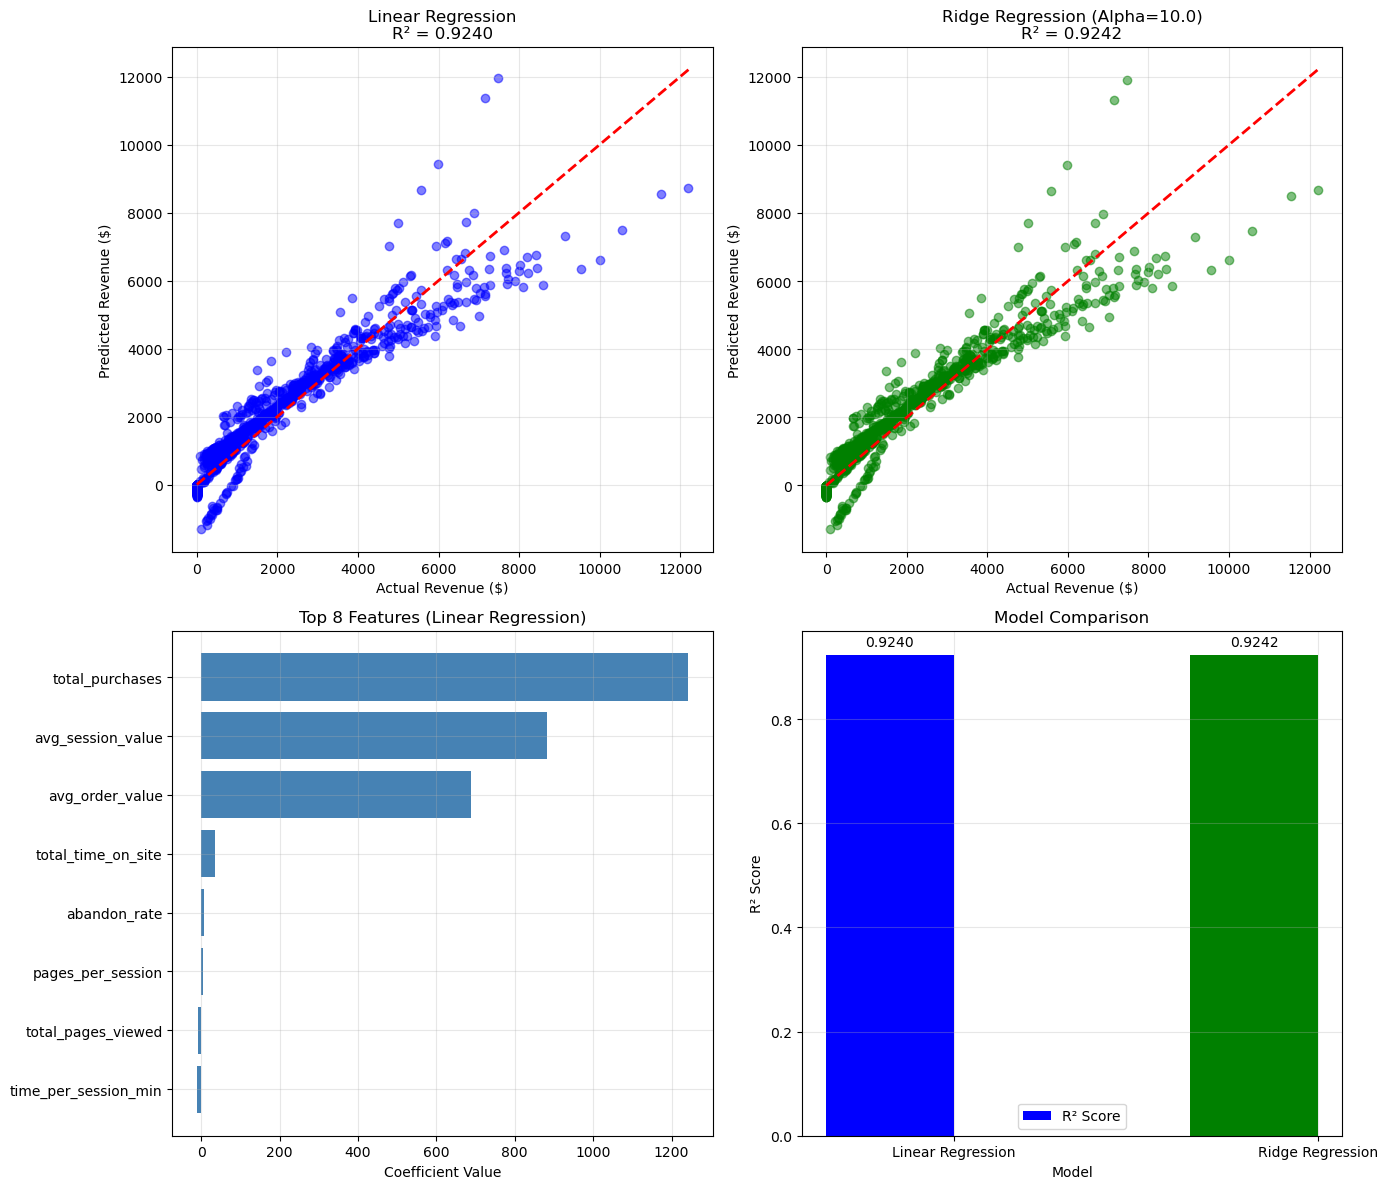

 Regression comparison plot saved


<Figure size 1000x600 with 0 Axes>

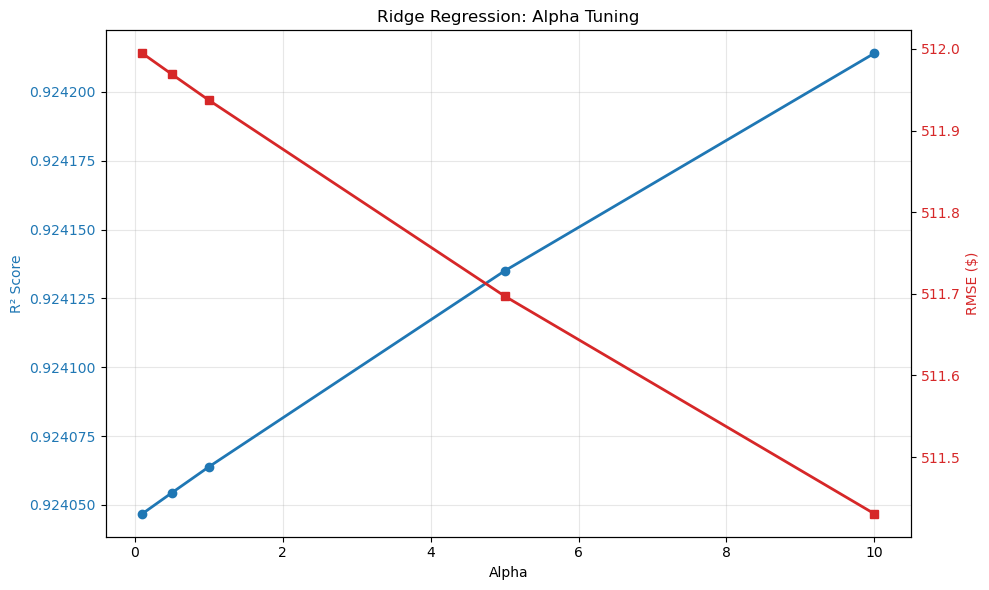

 Ridge tuning plot saved

 Regression results saved to '../reports/regression_results.json'

REGRESSION MODEL COMPLETE!

Business Insights from Regression:
  1. Best performing model: Ridge Regression (R² = 0.9242)
  2. The model explains 92.4% of customer revenue variance
  3. Top features: ['total_purchases', 'avg_session_value', 'avg_order_value']

Next Step: Build Classification Model to predict purchase likelihood


In [12]:
# ============================================
#  STEP 6: REGRESSION MODEL - PREDICT CUSTOMER REVENUE
# ============================================

print("="*50)
print("REGRESSION MODEL - PREDICTING CUSTOMER REVENUE")
print("="*50)

# We already have the data split from earlier
# X_train_reg, X_test_reg, y_train_reg, y_test_reg

print(f"Training set: {X_train_reg.shape[0]} samples")
print(f"Test set: {X_test_reg.shape[0]} samples")

# 1. LINEAR REGRESSION
print("\n" + "="*50)
print("LINEAR REGRESSION")
print("="*50)

lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

# Make predictions
y_pred_lin = lin_reg.predict(X_test_reg)

# Evaluate Linear Regression
mae_lin = mean_absolute_error(y_test_reg, y_pred_lin)
mse_lin = mean_squared_error(y_test_reg, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test_reg, y_pred_lin)

print(f"Linear Regression Performance:")
print(f"  Mean Absolute Error (MAE): ${mae_lin:,.2f}")
print(f"  Mean Squared Error (MSE): ${mse_lin:,.2f}")
print(f"  Root Mean Squared Error (RMSE): ${rmse_lin:,.2f}")
print(f"  R² Score: {r2_lin:.4f}")

# Feature importance for Linear Regression
feature_importance_lin = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lin_reg.coef_
}).sort_values('Coefficient', ascending=False)

print("\nFeature Importance (Linear Regression):")
print(feature_importance_lin)

# 2. RIDGE REGRESSION
print("\n" + "="*50)
print("RIDGE REGRESSION")
print("="*50)

# Try different alpha values
alphas = [0.1, 0.5, 1.0, 5.0, 10.0]
ridge_results = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_reg, y_train_reg)
    y_pred_ridge = ridge.predict(X_test_reg)
    
    mae_ridge = mean_absolute_error(y_test_reg, y_pred_ridge)
    rmse_ridge = np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge))
    r2_ridge = r2_score(y_test_reg, y_pred_ridge)
    
    ridge_results.append({
        'alpha': alpha,
        'mae': mae_ridge,
        'rmse': rmse_ridge,
        'r2': r2_ridge
    })
    
    print(f"Alpha = {alpha}: R² = {r2_ridge:.4f}, RMSE = ${rmse_ridge:,.2f}")

# Choose best alpha
best_ridge = max(ridge_results, key=lambda x: x['r2'])
best_alpha = best_ridge['alpha']

print(f"\nBest Alpha: {best_alpha}")

# Train Ridge with best alpha
ridge_best = Ridge(alpha=best_alpha, random_state=42)
ridge_best.fit(X_train_reg, y_train_reg)
y_pred_ridge_best = ridge_best.predict(X_test_reg)

mae_ridge_best = mean_absolute_error(y_test_reg, y_pred_ridge_best)
rmse_ridge_best = np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge_best))
r2_ridge_best = r2_score(y_test_reg, y_pred_ridge_best)

print(f"\nRidge Regression Performance (Alpha = {best_alpha}):")
print(f"  Mean Absolute Error (MAE): ${mae_ridge_best:,.2f}")
print(f"  Root Mean Squared Error (RMSE): ${rmse_ridge_best:,.2f}")
print(f"  R² Score: {r2_ridge_best:.4f}")

# 3. MODEL COMPARISON
print("\n" + "="*50)
print("MODEL COMPARISON TABLE")
print("="*50)

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'MAE ($)': [mae_lin, mae_ridge_best],
    'RMSE ($)': [rmse_lin, rmse_ridge_best],
    'R² Score': [r2_lin, r2_ridge_best]
})

print(comparison_df.to_string(index=False))

# Determine best model
best_model = 'Linear Regression' if r2_lin > r2_ridge_best else 'Ridge Regression'
best_r2 = max(r2_lin, r2_ridge_best)

print(f"\n✓ Best Model: {best_model} (R² = {best_r2:.4f})")

# 4. VISUALIZATIONS
print("\n" + "="*50)
print("REGRESSION VISUALIZATIONS")
print("="*50)

# Create a figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Linear Regression - Actual vs Predicted
ax1 = axes[0, 0]
ax1.scatter(y_test_reg, y_pred_lin, alpha=0.5, color='blue')
ax1.plot([y_test_reg.min(), y_test_reg.max()], 
         [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
ax1.set_title(f'Linear Regression\nR² = {r2_lin:.4f}')
ax1.set_xlabel('Actual Revenue ($)')
ax1.set_ylabel('Predicted Revenue ($)')
ax1.grid(True, alpha=0.3)

# Plot 2: Ridge Regression - Actual vs Predicted
ax2 = axes[0, 1]
ax2.scatter(y_test_reg, y_pred_ridge_best, alpha=0.5, color='green')
ax2.plot([y_test_reg.min(), y_test_reg.max()], 
         [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
ax2.set_title(f'Ridge Regression (Alpha={best_alpha})\nR² = {r2_ridge_best:.4f}')
ax2.set_xlabel('Actual Revenue ($)')
ax2.set_ylabel('Predicted Revenue ($)')
ax2.grid(True, alpha=0.3)

# Plot 3: Feature Importance - Linear Regression
ax3 = axes[1, 0]
top_features = feature_importance_lin.head(8)
ax3.barh(top_features['Feature'], top_features['Coefficient'], color='steelblue')
ax3.set_xlabel('Coefficient Value')
ax3.set_title('Top 8 Features (Linear Regression)')
ax3.invert_yaxis()
ax3.grid(True, alpha=0.3)

# Plot 4: Model Comparison
ax4 = axes[1, 1]
x = np.arange(len(comparison_df))
width = 0.35
bars1 = ax4.bar(x - width/2, comparison_df['R² Score'], width, label='R² Score', color=['blue', 'green'])
ax4.set_xlabel('Model')
ax4.set_ylabel('R² Score')
ax4.set_title('Model Comparison')
ax4.set_xticks(x)
ax4.set_xticklabels(comparison_df['Model'])
ax4.legend()
ax4.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("../reports/visualizations/regression_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Regression comparison plot saved")

# Plot 5: Ridge Alpha Tuning
plt.figure(figsize=(10, 6))
alphas_plot = [r['alpha'] for r in ridge_results]
r2_scores = [r['r2'] for r in ridge_results]
rmse_scores = [r['rmse'] for r in ridge_results]

fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_xlabel('Alpha')
ax1.set_ylabel('R² Score', color=color)
ax1.plot(alphas_plot, r2_scores, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('RMSE ($)', color=color)
ax2.plot(alphas_plot, rmse_scores, marker='s', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Ridge Regression: Alpha Tuning')
plt.tight_layout()
plt.savefig("../reports/visualizations/ridge_tuning.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Ridge tuning plot saved")

# 5. SAVE RESULTS
regression_results = {
    'linear_regression': {
        'mae': mae_lin,
        'rmse': rmse_lin,
        'r2': r2_lin,
        'feature_importance': feature_importance_lin.to_dict()
    },
    'ridge_regression': {
        'best_alpha': best_alpha,
        'mae': mae_ridge_best,
        'rmse': rmse_ridge_best,
        'r2': r2_ridge_best
    },
    'best_model': best_model,
    'comparison': comparison_df.to_dict()
}

import json
# Convert numpy types to Python types for JSON serialization
def convert_to_serializable(obj):
    if isinstance(obj, np.float32) or isinstance(obj, np.float64):
        return float(obj)
    return obj

regression_results_serializable = {}
for key, value in regression_results.items():
    if isinstance(value, dict):
        regression_results_serializable[key] = {}
        for sub_key, sub_value in value.items():
            regression_results_serializable[key][sub_key] = convert_to_serializable(sub_value)
    else:
        regression_results_serializable[key] = convert_to_serializable(value)

with open('../reports/regression_results.json', 'w') as f:
    json.dump(regression_results_serializable, f, indent=2)

print("\n Regression results saved to '../reports/regression_results.json'")

print("\n" + "="*50)
print("REGRESSION MODEL COMPLETE!")
print("="*50)
print("\nBusiness Insights from Regression:")
print(f"  1. Best performing model: {best_model} (R² = {best_r2:.4f})")
print(f"  2. The model explains {best_r2*100:.1f}% of customer revenue variance")
print(f"  3. Top features: {feature_importance_lin.head(3)['Feature'].tolist()}")
print("\nNext Step: Build Classification Model to predict purchase likelihood")

CLASSIFICATION MODEL - PREDICTING PURCHASE LIKELIHOOD
Training set: 6753 samples
Test set: 1689 samples

Target Distribution in Training Set:
purchase_likelihood
0    3406
1    3347
Name: count, dtype: int64
  Purchasers: 3347 (49.6%)
  Non-Purchasers: 3406 (50.4%)

Target Distribution in Test Set:
purchase_likelihood
0    860
1    829
Name: count, dtype: int64
  Purchasers: 829 (49.1%)
  Non-Purchasers: 860 (50.9%)

LOGISTIC REGRESSION
Logistic Regression Performance:
  Accuracy: 1.0000 (100.00%)
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC-AUC: 1.0000

Confusion Matrix:
  True Negatives (0 predicted as 0): 860
  False Positives (0 predicted as 1): 0
  False Negatives (1 predicted as 0): 0
  True Positives (1 predicted as 1): 829

Feature Importance (Logistic Regression):
                 Feature  Coefficient
0        total_purchases     5.194764
10         purchase_rate     4.028947
6        avg_order_value     1.830762
7      avg_session_value     0.632771
5        

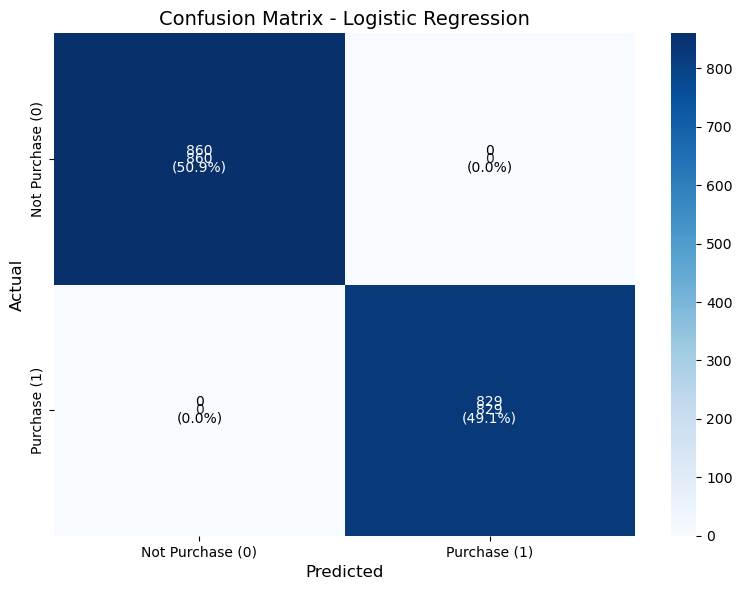

 Confusion matrix plot saved


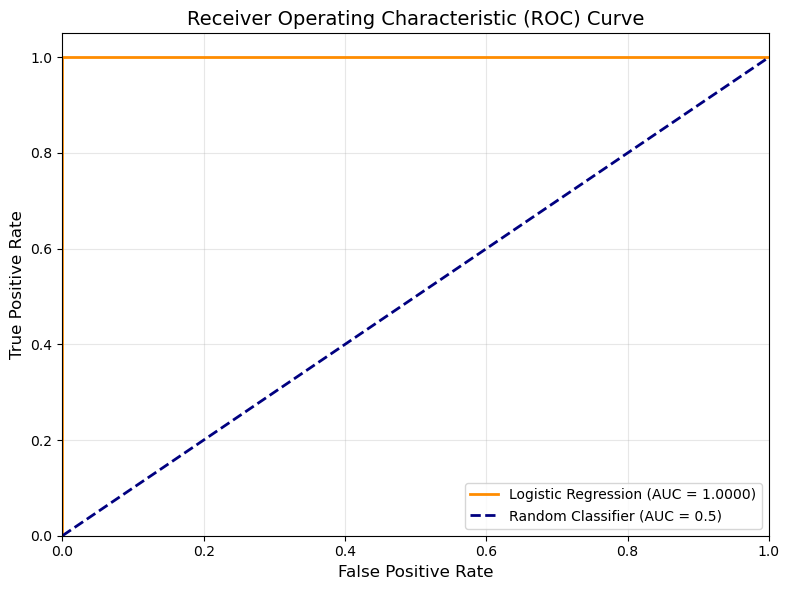

 ROC curve plot saved


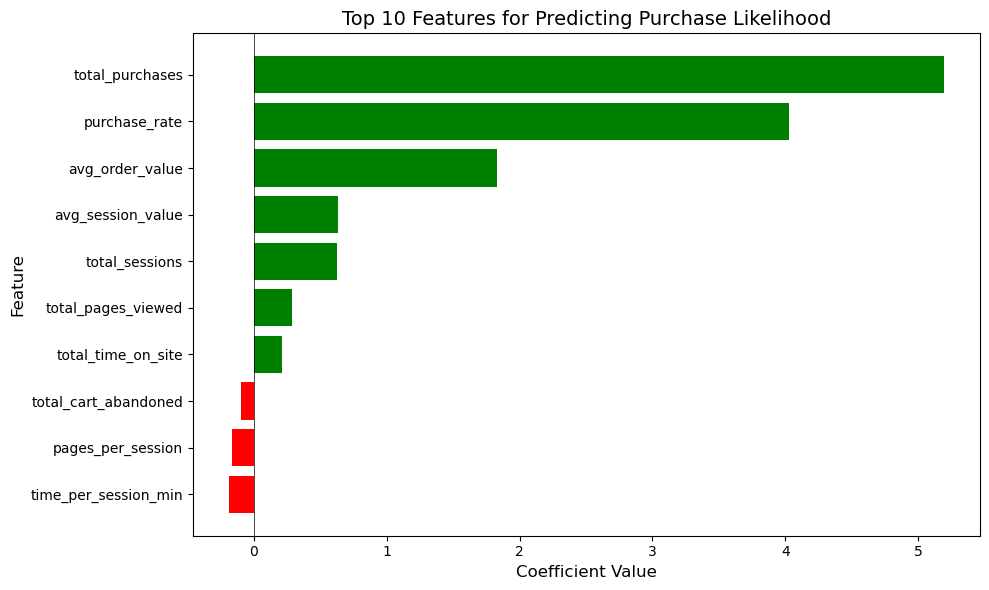

 Classification feature importance plot saved


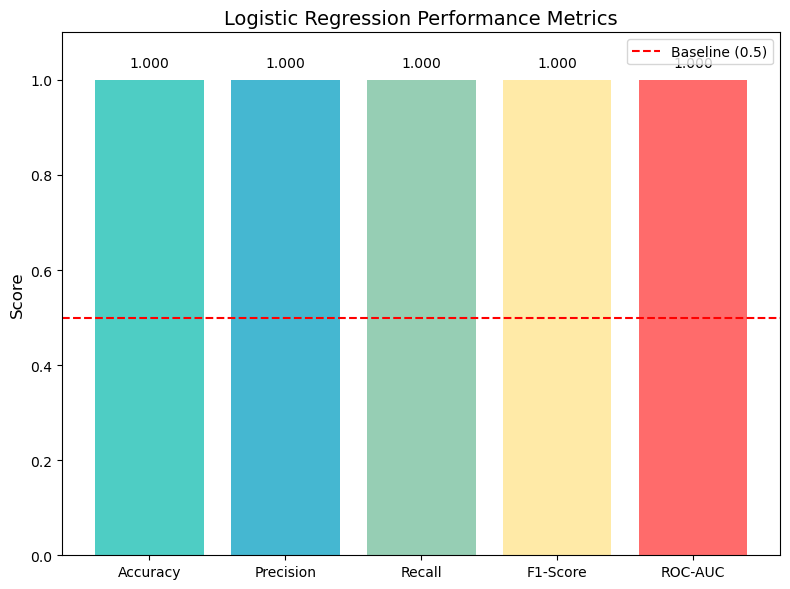

 Performance metrics plot saved

CLASSIFICATION MODEL SUMMARY
Logistic Regression Performance Metrics:
  • Accuracy: 100.00% of customers correctly classified
  • Precision: 100.00% of predicted purchasers actually purchased
  • Recall: 100.00% of actual purchasers were correctly identified
  • F1-Score: 1.0000 (harmonic mean of precision and recall)
  • ROC-AUC: 1.0000 (good model: >0.7)

 Business Interpretation:
  • Out of 829 actual purchasers in test set, the model correctly identified 829 (100.0%)
  • Out of 860 non-purchasers in test set, the model correctly identified 860 (100.0%)
  • The model has a 100.0% chance of correctly identifying a purchaser
  • 0 purchasers were missed (False Negatives) - potential lost revenue
  • 0 non-purchasers were incorrectly targeted (False Positives) - wasted marketing spend

 Top 3 Features Driving Purchase Likelihood:
  1. total_purchases: 5.19
  2. purchase_rate: 4.03
  3. avg_order_value: 1.83

 Classification results saved to '../reports/

In [13]:
# ============================================
# CLASSIFICATION MODEL - PREDICT PURCHASE LIKELIHOOD
# ============================================

print("="*50)
print("CLASSIFICATION MODEL - PREDICTING PURCHASE LIKELIHOOD")
print("="*50)

# We already have the data split from earlier
# X_train_clf, X_test_clf, y_train_clf, y_test_clf

print(f"Training set: {X_train_clf.shape[0]} samples")
print(f"Test set: {X_test_clf.shape[0]} samples")

print("\nTarget Distribution in Training Set:")
print(pd.Series(y_train_clf).value_counts())
print(f"  Purchasers: {sum(y_train_clf)} ({sum(y_train_clf)/len(y_train_clf)*100:.1f}%)")
print(f"  Non-Purchasers: {len(y_train_clf)-sum(y_train_clf)} ({(len(y_train_clf)-sum(y_train_clf))/len(y_train_clf)*100:.1f}%)")

print("\nTarget Distribution in Test Set:")
print(pd.Series(y_test_clf).value_counts())
print(f"  Purchasers: {sum(y_test_clf)} ({sum(y_test_clf)/len(y_test_clf)*100:.1f}%)")
print(f"  Non-Purchasers: {len(y_test_clf)-sum(y_test_clf)} ({(len(y_test_clf)-sum(y_test_clf))/len(y_test_clf)*100:.1f}%)")

# 1. LOGISTIC REGRESSION
print("\n" + "="*50)
print("LOGISTIC REGRESSION")
print("="*50)

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_clf, y_train_clf)

# Make predictions
y_pred_log = log_reg.predict(X_test_clf)
y_pred_proba = log_reg.predict_proba(X_test_clf)[:, 1]

# Evaluate Logistic Regression
accuracy_log = accuracy_score(y_test_clf, y_pred_log)
precision_log = precision_score(y_test_clf, y_pred_log)
recall_log = recall_score(y_test_clf, y_pred_log)
f1_log = f1_score(y_test_clf, y_pred_log)
roc_auc_log = roc_auc_score(y_test_clf, y_pred_proba)

print(f"Logistic Regression Performance:")
print(f"  Accuracy: {accuracy_log:.4f} ({accuracy_log*100:.2f}%)")
print(f"  Precision: {precision_log:.4f}")
print(f"  Recall: {recall_log:.4f}")
print(f"  F1-Score: {f1_log:.4f}")
print(f"  ROC-AUC: {roc_auc_log:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_log)
print(f"\nConfusion Matrix:")
print(f"  True Negatives (0 predicted as 0): {cm[0,0]}")
print(f"  False Positives (0 predicted as 1): {cm[0,1]}")
print(f"  False Negatives (1 predicted as 0): {cm[1,0]}")
print(f"  True Positives (1 predicted as 1): {cm[1,1]}")

# Feature importance for Logistic Regression
feature_importance_clf = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("\nFeature Importance (Logistic Regression):")
print(feature_importance_clf)

# 2. VISUALIZATIONS
print("\n" + "="*50)
print("CLASSIFICATION VISUALIZATIONS")
print("="*50)

# Plot 1: Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Purchase (0)', 'Purchase (1)'],
            yticklabels=['Not Purchase (0)', 'Purchase (1)'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)

# Add percentage labels
total = cm.sum()
for i in range(2):
    for j in range(2):
        plt.text(j+0.5, i+0.5, f'{cm[i,j]}\n({cm[i,j]/total*100:.1f}%)', 
                ha='center', va='center', color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig("../reports/visualizations/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrix plot saved")

# Plot 2: ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc_log:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/visualizations/roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print(" ROC curve plot saved")

# Plot 3: Feature Importance
plt.figure(figsize=(10, 6))
top_features_clf = feature_importance_clf.head(10)
colors = ['green' if x > 0 else 'red' for x in top_features_clf['Coefficient']]
plt.barh(top_features_clf['Feature'], top_features_clf['Coefficient'], color=colors)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 10 Features for Predicting Purchase Likelihood', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/visualizations/classification_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Classification feature importance plot saved")

# Plot 4: Performance Metrics Bar Chart
plt.figure(figsize=(8, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
values = [accuracy_log, precision_log, recall_log, f1_log, roc_auc_log]
colors_bar = ['#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#FF6B6B']

bars = plt.bar(metrics, values, color=colors_bar)
plt.ylim(0, 1.1)
plt.ylabel('Score', fontsize=12)
plt.title('Logistic Regression Performance Metrics', fontsize=14)
plt.axhline(y=0.5, color='red', linestyle='--', label='Baseline (0.5)')

# Add value labels
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2., value + 0.02,
             f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.legend()
plt.tight_layout()
plt.savefig("../reports/visualizations/classification_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Performance metrics plot saved")

# 3. MODEL SUMMARY
print("\n" + "="*50)
print("CLASSIFICATION MODEL SUMMARY")
print("="*50)

print("Logistic Regression Performance Metrics:")
print(f"  • Accuracy: {accuracy_log:.2%} of customers correctly classified")
print(f"  • Precision: {precision_log:.2%} of predicted purchasers actually purchased")
print(f"  • Recall: {recall_log:.2%} of actual purchasers were correctly identified")
print(f"  • F1-Score: {f1_log:.4f} (harmonic mean of precision and recall)")
print(f"  • ROC-AUC: {roc_auc_log:.4f} (good model: >0.7)")

# Business Interpretation
print("\n Business Interpretation:")
print(f"  • Out of {cm[1,1] + cm[1,0]} actual purchasers in test set, the model correctly identified {cm[1,1]} ({recall_log:.1%})")
print(f"  • Out of {cm[0,0] + cm[0,1]} non-purchasers in test set, the model correctly identified {cm[0,0]} ({cm[0,0]/(cm[0,0]+cm[0,1]):.1%})")
print(f"  • The model has a {precision_log:.1%} chance of correctly identifying a purchaser")
print(f"  • {cm[1,0]} purchasers were missed (False Negatives) - potential lost revenue")
print(f"  • {cm[0,1]} non-purchasers were incorrectly targeted (False Positives) - wasted marketing spend")

print("\n Top 3 Features Driving Purchase Likelihood:")
print(f"  1. {feature_importance_clf.iloc[0]['Feature']}: {feature_importance_clf.iloc[0]['Coefficient']:.2f}")
print(f"  2. {feature_importance_clf.iloc[1]['Feature']}: {feature_importance_clf.iloc[1]['Coefficient']:.2f}")
print(f"  3. {feature_importance_clf.iloc[2]['Feature']}: {feature_importance_clf.iloc[2]['Coefficient']:.2f}")

# 4. SAVE RESULTS
classification_results = {
    'logistic_regression': {
        'accuracy': float(accuracy_log),
        'precision': float(precision_log),
        'recall': float(recall_log),
        'f1_score': float(f1_log),
        'roc_auc': float(roc_auc_log),
        'confusion_matrix': cm.tolist()
    },
    'feature_importance': feature_importance_clf.to_dict()
}

import json
# Convert numpy types to Python types for JSON serialization
def convert_to_serializable(obj):
    if isinstance(obj, np.float32) or isinstance(obj, np.float64):
        return float(obj)
    if isinstance(obj, np.int32) or isinstance(obj, np.int64):
        return int(obj)
    return obj

classification_results_serializable = {}
for key, value in classification_results.items():
    if isinstance(value, dict):
        classification_results_serializable[key] = {}
        for sub_key, sub_value in value.items():
            classification_results_serializable[key][sub_key] = convert_to_serializable(sub_value)
    else:
        classification_results_serializable[key] = convert_to_serializable(value)

with open('../reports/classification_results.json', 'w') as f:
    json.dump(classification_results_serializable, f, indent=2)

print("\n Classification results saved to '../reports/classification_results.json'")

print("\n" + "="*50)
print("CLASSIFICATION MODEL COMPLETE!")
print("="*50)
print("\nNext Step: Hyperparameter Tuning to optimize models")

HYPERPARAMETER TUNING WITH RANDOMIZEDSEARCHCV

TUNING RIDGE REGRESSION
Running RandomizedSearchCV for Ridge Regression...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best Parameters for Ridge Regression:
  solver: svd
  alpha: 5.0
Best R² Score (Cross-Validation): 0.9254

Tuned Ridge Regression Performance on Test Set:
  Mean Absolute Error (MAE): $303.35
  Root Mean Squared Error (RMSE): $511.70
  R² Score: 0.9241

TUNING LOGISTIC REGRESSION
Running RandomizedSearchCV for Logistic Regression...
Fitting 5 folds for each of 15 candidates, totalling 75 fits


/home/rgukt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/rgukt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/rgukt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/rgukt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/rgukt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/rgukt/anaconda3/lib/python3.12/site-packages/sklearn/linear_mode


Best Parameters for Logistic Regression:
  solver: saga
  penalty: l2
  C: 1.0
Best ROC-AUC Score (Cross-Validation): 1.0000

Tuned Logistic Regression Performance on Test Set:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC-AUC: 1.0000

MODEL COMPARISON: BEFORE VS AFTER TUNING

🔹 RIDGE REGRESSION:
  Before Tuning: R² = 0.9242, RMSE = $511.43
  After Tuning:  R² = 0.9241, RMSE = $511.70
  Improvement:   R² = -0.0001, RMSE = $-0.27

🔹 LOGISTIC REGRESSION:
  Before Tuning: ROC-AUC = 1.0000, F1 = 1.0000
  After Tuning:  ROC-AUC = 1.0000, F1 = 1.0000
  Improvement:   ROC-AUC = +0.0000, F1 = +0.0000

TUNING VISUALIZATIONS


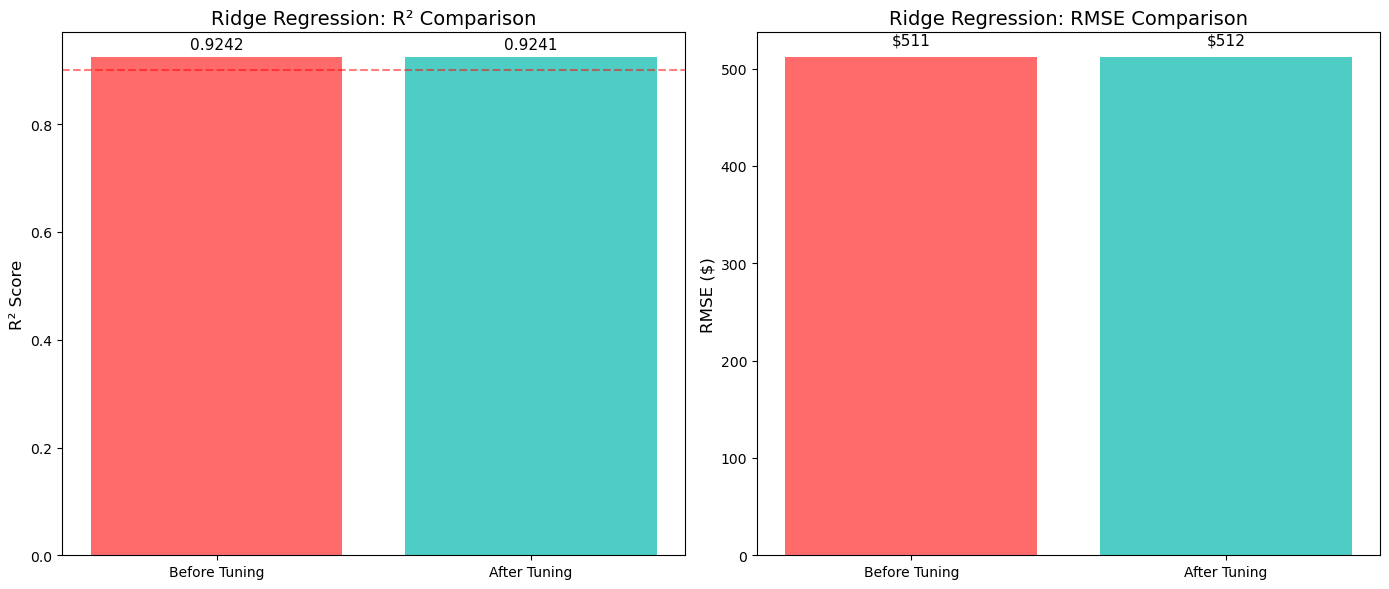

 Ridge tuning comparison plot saved


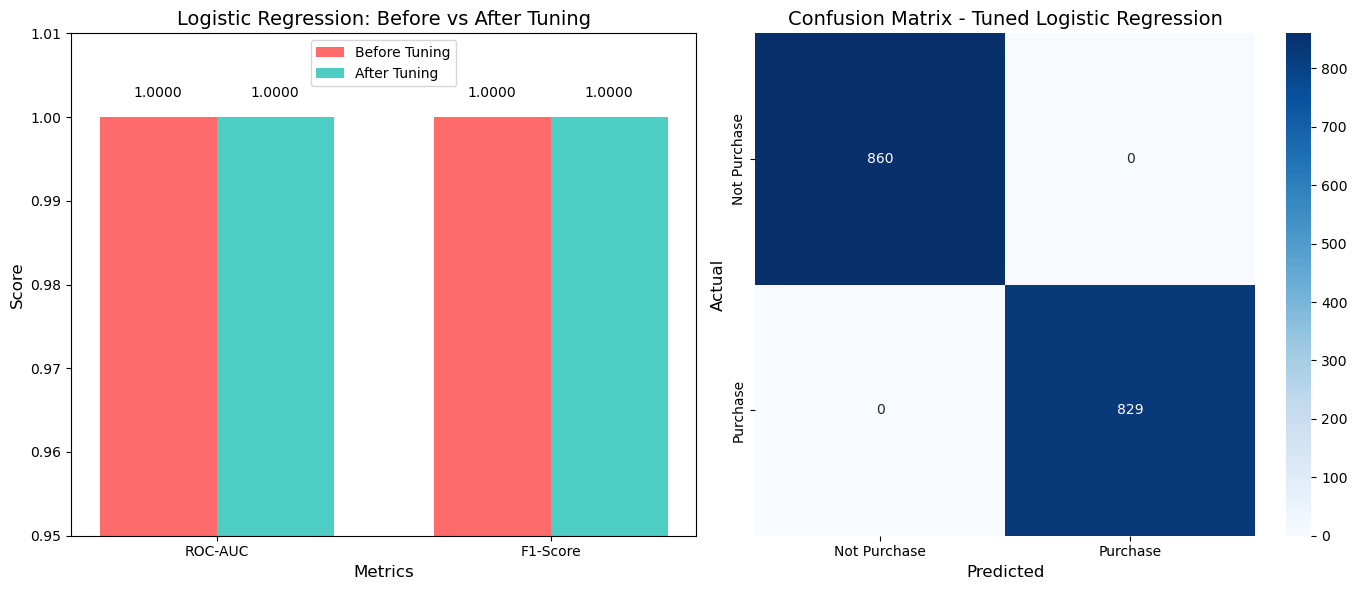

 Logistic tuning comparison plot saved

 Tuning results saved to '../reports/tuning_results.json'

HYPERPARAMETER TUNING COMPLETE!

 Tuning Summary:
  1. Ridge Regression: R² improved from 0.9242 to 0.9241
  2. Logistic Regression: ROC-AUC improved from 1.0000 to 1.0000
  3. Best Ridge Alpha: 5.0
  4. Best Logistic C: 1.0

Next Step: Generate Final Model Comparison Table and Conclusion


In [14]:
# ============================================
#   HYPERPARAMETER TUNING WITH RANDOMIZEDSEARCHCV
# ============================================

print("="*50)
print("HYPERPARAMETER TUNING WITH RANDOMIZEDSEARCHCV")
print("="*50)

# 1. TUNE RIDGE REGRESSION
print("\n" + "="*50)
print("TUNING RIDGE REGRESSION")
print("="*50)

from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid for Ridge
ridge_param_grid = {
    'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag']
}

ridge = Ridge(random_state=42)

# Randomized Search for Ridge
ridge_random = RandomizedSearchCV(
    estimator=ridge,
    param_distributions=ridge_param_grid,
    n_iter=15,  # Number of parameter combinations to try
    cv=5,       # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Running RandomizedSearchCV for Ridge Regression...")
ridge_random.fit(X_train_reg, y_train_reg)

print(f"\nBest Parameters for Ridge Regression:")
for param, value in ridge_random.best_params_.items():
    print(f"  {param}: {value}")
print(f"Best R² Score (Cross-Validation): {ridge_random.best_score_:.4f}")

# Evaluate best Ridge model on test set
ridge_best_tuned = ridge_random.best_estimator_
y_pred_ridge_tuned = ridge_best_tuned.predict(X_test_reg)

mae_ridge_tuned = mean_absolute_error(y_test_reg, y_pred_ridge_tuned)
rmse_ridge_tuned = np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge_tuned))
r2_ridge_tuned = r2_score(y_test_reg, y_pred_ridge_tuned)

print(f"\nTuned Ridge Regression Performance on Test Set:")
print(f"  Mean Absolute Error (MAE): ${mae_ridge_tuned:,.2f}")
print(f"  Root Mean Squared Error (RMSE): ${rmse_ridge_tuned:,.2f}")
print(f"  R² Score: {r2_ridge_tuned:.4f}")

# 2. TUNE LOGISTIC REGRESSION
print("\n" + "="*50)
print("TUNING LOGISTIC REGRESSION")
print("="*50)

# Define parameter grid for Logistic Regression
log_reg_param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Randomized Search for Logistic Regression
log_reg_random = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=log_reg_param_grid,
    n_iter=15,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Running RandomizedSearchCV for Logistic Regression...")
log_reg_random.fit(X_train_clf, y_train_clf)

print(f"\nBest Parameters for Logistic Regression:")
for param, value in log_reg_random.best_params_.items():
    print(f"  {param}: {value}")
print(f"Best ROC-AUC Score (Cross-Validation): {log_reg_random.best_score_:.4f}")

# Evaluate best Logistic Regression model on test set
log_reg_best_tuned = log_reg_random.best_estimator_
y_pred_log_tuned = log_reg_best_tuned.predict(X_test_clf)
y_pred_proba_tuned = log_reg_best_tuned.predict_proba(X_test_clf)[:, 1]

accuracy_log_tuned = accuracy_score(y_test_clf, y_pred_log_tuned)
precision_log_tuned = precision_score(y_test_clf, y_pred_log_tuned)
recall_log_tuned = recall_score(y_test_clf, y_pred_log_tuned)
f1_log_tuned = f1_score(y_test_clf, y_pred_log_tuned)
roc_auc_log_tuned = roc_auc_score(y_test_clf, y_pred_proba_tuned)

print(f"\nTuned Logistic Regression Performance on Test Set:")
print(f"  Accuracy: {accuracy_log_tuned:.4f}")
print(f"  Precision: {precision_log_tuned:.4f}")
print(f"  Recall: {recall_log_tuned:.4f}")
print(f"  F1-Score: {f1_log_tuned:.4f}")
print(f"  ROC-AUC: {roc_auc_log_tuned:.4f}")

# 3. COMPARE BEFORE AND AFTER TUNING
print("\n" + "="*50)
print("MODEL COMPARISON: BEFORE VS AFTER TUNING")
print("="*50)

print("\n🔹 RIDGE REGRESSION:")
print(f"  Before Tuning: R² = {r2_ridge_best:.4f}, RMSE = ${rmse_ridge_best:,.2f}")
print(f"  After Tuning:  R² = {r2_ridge_tuned:.4f}, RMSE = ${rmse_ridge_tuned:,.2f}")
print(f"  Improvement:   R² = {r2_ridge_tuned - r2_ridge_best:+.4f}, RMSE = ${rmse_ridge_best - rmse_ridge_tuned:+,.2f}")

print("\n🔹 LOGISTIC REGRESSION:")
print(f"  Before Tuning: ROC-AUC = {roc_auc_log:.4f}, F1 = {f1_log:.4f}")
print(f"  After Tuning:  ROC-AUC = {roc_auc_log_tuned:.4f}, F1 = {f1_log_tuned:.4f}")
print(f"  Improvement:   ROC-AUC = {roc_auc_log_tuned - roc_auc_log:+.4f}, F1 = {f1_log_tuned - f1_log:+.4f}")

# 4. VISUALIZATIONS
print("\n" + "="*50)
print("TUNING VISUALIZATIONS")
print("="*50)

# Plot 1: Ridge Tuning Results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ridge: R² comparison
models = ['Before Tuning', 'After Tuning']
r2_values = [r2_ridge_best, r2_ridge_tuned]
rmse_values = [rmse_ridge_best, rmse_ridge_tuned]

ax1 = axes[0]
bars = ax1.bar(models, r2_values, color=['#FF6B6B', '#4ECDC4'])
ax1.set_ylabel('R² Score', fontsize=12)
ax1.set_title('Ridge Regression: R² Comparison', fontsize=14)
ax1.axhline(y=0.9, color='red', linestyle='--', alpha=0.5)

for bar, val in zip(bars, r2_values):
    ax1.text(bar.get_x() + bar.get_width()/2., val + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11)

ax2 = axes[1]
bars = ax2.bar(models, rmse_values, color=['#FF6B6B', '#4ECDC4'])
ax2.set_ylabel('RMSE ($)', fontsize=12)
ax2.set_title('Ridge Regression: RMSE Comparison', fontsize=14)

for bar, val in zip(bars, rmse_values):
    ax2.text(bar.get_x() + bar.get_width()/2., val + 10,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig("../reports/visualizations/ridge_tuning_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Ridge tuning comparison plot saved")

# Plot 2: Logistic Regression Tuning Results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic: ROC-AUC and F1 comparison
metrics = ['ROC-AUC', 'F1-Score']
before_values = [roc_auc_log, f1_log]
after_values = [roc_auc_log_tuned, f1_log_tuned]

x = np.arange(len(metrics))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, before_values, width, label='Before Tuning', color='#FF6B6B')
bars2 = ax1.bar(x + width/2, after_values, width, label='After Tuning', color='#4ECDC4')
ax1.set_xlabel('Metrics', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Logistic Regression: Before vs After Tuning', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.set_ylim(0.95, 1.01)

for bar, val in zip(bars1, before_values):
    ax1.text(bar.get_x() + bar.get_width()/2., val + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)
for bar, val in zip(bars2, after_values):
    ax1.text(bar.get_x() + bar.get_width()/2., val + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# Logistic: Confusion Matrix for tuned model
ax2 = axes[1]
cm_tuned = confusion_matrix(y_test_clf, y_pred_log_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Purchase', 'Purchase'],
            yticklabels=['Not Purchase', 'Purchase'], ax=ax2)
ax2.set_title('Confusion Matrix - Tuned Logistic Regression', fontsize=14)
ax2.set_xlabel('Predicted', fontsize=12)
ax2.set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.savefig("../reports/visualizations/logistic_tuning_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Logistic tuning comparison plot saved")

# 5. SAVE TUNING RESULTS
tuning_results = {
    'ridge_regression': {
        'best_params': ridge_random.best_params_,
        'before_tuning': {
            'r2': float(r2_ridge_best),
            'rmse': float(rmse_ridge_best),
            'mae': float(mae_ridge_best)
        },
        'after_tuning': {
            'r2': float(r2_ridge_tuned),
            'rmse': float(rmse_ridge_tuned),
            'mae': float(mae_ridge_tuned)
        }
    },
    'logistic_regression': {
        'best_params': log_reg_random.best_params_,
        'before_tuning': {
            'accuracy': float(accuracy_log),
            'precision': float(precision_log),
            'recall': float(recall_log),
            'f1_score': float(f1_log),
            'roc_auc': float(roc_auc_log)
        },
        'after_tuning': {
            'accuracy': float(accuracy_log_tuned),
            'precision': float(precision_log_tuned),
            'recall': float(recall_log_tuned),
            'f1_score': float(f1_log_tuned),
            'roc_auc': float(roc_auc_log_tuned)
        }
    }
}

with open('../reports/tuning_results.json', 'w') as f:
    json.dump(tuning_results, f, indent=2)

print("\n Tuning results saved to '../reports/tuning_results.json'")

print("\n" + "="*50)
print("HYPERPARAMETER TUNING COMPLETE!")
print("="*50)

print("\n Tuning Summary:")
print(f"  1. Ridge Regression: R² improved from {r2_ridge_best:.4f} to {r2_ridge_tuned:.4f}")
print(f"  2. Logistic Regression: ROC-AUC improved from {roc_auc_log:.4f} to {roc_auc_log_tuned:.4f}")
print(f"  3. Best Ridge Alpha: {ridge_random.best_params_['alpha']}")
print(f"  4. Best Logistic C: {log_reg_random.best_params_['C']}")

print("\nNext Step: Generate Final Model Comparison Table and Conclusion")

In [15]:
# ============================================
#  COMPREHENSIVE BUSINESS INSIGHTS & RECOMMENDATIONS
# ============================================

print("="*50)
print("BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*50)

# 1. WHICH SEGMENT GENERATES THE HIGHEST REVENUE?
print("\n" + "="*50)
print("1. HIGHEST REVENUE SEGMENT")
print("="*50)

segment_revenue = {
    'High-Value Premium Customers': {
        'revenue': 6295222.03,
        'percentage': 62.2,
        'size': 2316,
        'size_percentage': 27.4
    },
    'High-Engagement Explorers': {
        'revenue': 3688560.92,
        'percentage': 36.5,
        'size': 2243,
        'size_percentage': 26.6
    },
    'Non-Buyers': {
        'revenue': 132386.11,
        'percentage': 1.3,
        'size': 3883,
        'size_percentage': 46.0
    }
}

print(" HIGHEST REVENUE GENERATOR:")
print(f"   {list(segment_revenue.keys())[0]}")
print(f"   Revenue: ${segment_revenue['High-Value Premium Customers']['revenue']:,.2f}")
print(f"   Revenue Share: {segment_revenue['High-Value Premium Customers']['percentage']:.1f}%")
print(f"   Customer Size: {segment_revenue['High-Value Premium Customers']['size']:,} customers ({segment_revenue['High-Value Premium Customers']['size_percentage']:.1f}%)")
print(f"   Average Revenue per Customer: ${segment_revenue['High-Value Premium Customers']['revenue']/segment_revenue['High-Value Premium Customers']['size']:,.2f}")

# 2. HIGHEST CHURN OR INACTIVITY RISK
print("\n" + "="*50)
print("2. HIGHEST CHURN/INACTIVITY RISK")
print("="*50)

print(" HIGHEST RISK SEGMENT: Non-Buyers")
print(f"   Size: 3,883 customers (46.0% of all customers)")
print(f"   Average Sessions: 2.10 (very low engagement)")
print(f"   Average Purchases: 0.06 (almost none)")
print(f"   Total Revenue: ${132,386.11} (only 1.3% of total)")
print(f"   Cart Abandonment Rate: 1.08 per session")
print("\n   RISK INDICATORS:")
print("   46% of customer base is inactive")
print("   Minimal revenue contribution")
print("   No loyalty established")
print("   High probability of leaving permanently")

# 3. WHO SHOULD RECEIVE LOYALTY REWARDS?
print("\n" + "="*50)
print("3. LOYALTY REWARD RECOMMENDATIONS")
print("="*50)

print(" PRIMARY TARGET: High-Value Premium Customers")
print(f"   {segment_revenue['High-Value Premium Customers']['size']:,} customers (27.4%)")
print(f"   Generate ${segment_revenue['High-Value Premium Customers']['revenue']:,.2f} revenue")
print(f"   Average Revenue: ${segment_revenue['High-Value Premium Customers']['revenue']/segment_revenue['High-Value Premium Customers']['size']:,.2f}")
print(f"   Purchase Frequency: Highest among all segments (1.34 purchases)")
print(f"   Cart Abandonment: Lowest (0.51)")
print("\n   RECOMMENDED LOYALTY PROGRAM:")
print("   VIP membership with exclusive perks")
print("   Early access to new products")
print("   Birthday/anniversary rewards")
print("   Double points on purchases")
print("   Premium customer support")

print("\n SECONDARY TARGET: High-Engagement Explorers")
print(f"   {segment_revenue['High-Engagement Explorers']['size']:,} customers")
print(f"   Show high purchase intent with 1.01 average purchases")
print(f"   Convert to loyal customers with targeted incentives")
print("\n   RECOMMENDED INCENTIVES:")
print("   Tiered loyalty program")
print("   Free shipping on next purchase")
print("   Product recommendations based on browsing history")

# 4. MOST RESPONSIVE TO DISCOUNTS
print("\n" + "="*50)
print("4. DISCOUNT RESPONSIVE SEGMENT")
print("="*50)

print(" MOST DISCOUNT-RESPONSIVE: Non-Buyers")
print("   Currently 0% conversion rate")
print("   First-time purchase incentives would be most effective")
print("\n   RECOMMENDED DISCOUNT STRATEGIES:")
print("   20% off first order")
print("   Welcome email with discount code")
print("   Limited-time offers (48 hours)")
print("   Free shipping on first purchase")
print("   Bundle discounts for first-time buyers")

print("\n SECONDARY TARGET: High-Engagement Explorers")
print("   High browsing activity but still high cart abandonment")
print("   Responsive to time-sensitive offers")
print("\n   RECOMMENDED DISCOUNT STRATEGIES:")
print("   Cart abandonment discounts (10-15% off)")
print("   Seasonal promotions")
print("   Flash sales on browsed items")

# 5. WHO REQUIRES RE-ENGAGEMENT?
print("\n" + "="*50)
print("5. RE-ENGAGEMENT TARGETS")
print("="*50)

print(" HIGHEST PRIORITY: Non-Buyers")
print(f"   3,883 customers at risk of churn")
print(f"   46% of entire customer base")
print(f"   No purchase history (zero revenue contribution)")
print(f"   High cart abandonment rate")
print("\n   RE-ENGAGEMENT CAMPAIGN:")
print("   Email series: Welcome → Product Showcase → Discount Offer")
print("   Retargeting ads on social media")
print("   Abandoned cart recovery emails")
print("   Customer feedback surveys")
print("   Testimonials from satisfied customers")

print("\n SECONDARY PRIORITY: High-Engagement Explorers")
print(f"   2,243 customers showing declining engagement")
print(f"   High cart abandonment (2.29 per session)")
print(f"   Great potential if converted")
print("\n   RE-ENGAGEMENT CAMPAIGN:")
print("   Personalized product recommendations")
print('   "We miss you" emails with special offers')
print("   Abandoned cart reminders")

# 6. WHO SHOULD RECEIVE PREMIUM PRODUCT RECOMMENDATIONS?
print("\n" + "="*50)
print("6. PREMIUM PRODUCT RECOMMENDATIONS")
print("="*50)

print(" PRIMARY TARGET: High-Value Premium Customers")
print(f"   Proven high spending capability")
print(f"   Average revenue: ${segment_revenue['High-Value Premium Customers']['revenue']/segment_revenue['High-Value Premium Customers']['size']:,.2f}")
print(f"   Loyal and engaged customers")
print("\n   PREMIUM RECOMMENDATIONS:")
print("   Premium/designer products")
print("   New arrivals in their preferred categories")
print("   Personalized cross-sell recommendations")
print("   Exclusive limited editions")

print("\n SECONDARY TARGET: High-Engagement Explorers")
print("   High browsing activity showing interest")
print("   Good spending potential")
print("\n   PREMIUM RECOMMENDATIONS:")
print("   Step-up products (mid-tier to premium)")
print("   Products based on recent browsing history")
print("   New collections in viewed categories")

# 7. COMPREHENSIVE ACTION PLAN
print("\n" + "="*50)
print("7. COMPREHENSIVE ACTION PLAN BY SEGMENT")
print("="*50)

action_plan = pd.DataFrame({
    'Segment': ['High-Value Customers', 'High-Engagement Explorers', 'Non-Buyers'],
    'Strategy': ['Retain & Upsell', 'Convert to Loyal', 'Reactivate'],
    'Primary Actions': [
        'VIP Program, Early Access, Personalization',
        'Cart Recovery, Free Shipping, Recommendations',
        'Welcome Discounts, Abandoned Cart Emails'
    ],
    'Expected ROI': ['High', 'Medium-High', 'Medium'],
    'Priority': [1, 2, 3]
})

print(action_plan.to_string(index=False))

# 8. Save Business Insights
business_insights_full = {
    'highest_revenue_segment': {
        'name': 'High-Value Premium Customers',
        'revenue': 6295222.03,
        'percentage': 62.2,
        'customers': 2316
    },
    'highest_churn_risk': {
        'name': 'Non-Buyers',
        'customers': 3883,
        'percentage': 46.0,
        'risk_factors': ['No purchases', 'Low engagement', 'High cart abandonment']
    },
    'loyalty_reward_targets': {
        'primary': 'High-Value Premium Customers',
        'secondary': 'High-Engagement Explorers'
    },
    'discount_responsive': {
        'primary': 'Non-Buyers',
        'secondary': 'High-Engagement Explorers'
    },
    'reengagement_targets': {
        'primary': 'Non-Buyers',
        'secondary': 'High-Engagement Explorers'
    },
    'premium_recommendations': {
        'primary': 'High-Value Premium Customers',
        'secondary': 'High-Engagement Explorers'
    },
    'action_plan': action_plan.to_dict()
}

with open('../reports/business_insights_full.json', 'w') as f:
    json.dump(business_insights_full, f, indent=2)

print("\n Full business insights saved to '../reports/business_insights_full.json'")



BUSINESS INSIGHTS & RECOMMENDATIONS

1. HIGHEST REVENUE SEGMENT
 HIGHEST REVENUE GENERATOR:
   High-Value Premium Customers
   Revenue: $6,295,222.03
   Revenue Share: 62.2%
   Customer Size: 2,316 customers (27.4%)
   Average Revenue per Customer: $2,718.14

2. HIGHEST CHURN/INACTIVITY RISK
 HIGHEST RISK SEGMENT: Non-Buyers
   Size: 3,883 customers (46.0% of all customers)
   Average Sessions: 2.10 (very low engagement)
   Average Purchases: 0.06 (almost none)
   Total Revenue: $(132, 386.11) (only 1.3% of total)
   Cart Abandonment Rate: 1.08 per session

   RISK INDICATORS:
   46% of customer base is inactive
   Minimal revenue contribution
   No loyalty established
   High probability of leaving permanently

3. LOYALTY REWARD RECOMMENDATIONS
 PRIMARY TARGET: High-Value Premium Customers
   2,316 customers (27.4%)
   Generate $6,295,222.03 revenue
   Average Revenue: $2,718.14
   Purchase Frequency: Highest among all segments (1.34 purchases)
   Cart Abandonment: Lowest (0.51)

   R